<a href="https://colab.research.google.com/github/caxios/MLDS/blob/main/%EC%96%B4%EB%8B%9D_%EC%87%BC%ED%81%AC_%EC%98%88%EC%B8%A1_%EB%AA%A8%ED%98%95%2C_%ED%8C%A9%ED%84%B0_%EB%AA%A8%ED%98%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 패키지 임포트, 파일 경로 선언

In [1]:
!sudo apt-get install -y fonts-nanum --quiet
!sudo fc-cache -fv --quiet
!rm ~/.cache/matplotlib -rf --quiet
!pip install linearmodels --quiet

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (62.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm
import matplotlib.pyplot as plt
import logging
import warnings

# 사전 설치 필요: pip install linearmodels
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# Matplotlib 폰트 경고 및 기타 경고 끄기
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore')

# 기본 폰트 설정 (경고 방지를 위해 Nanum 대신 기본 sans-serif 사용 권장)
plt.rc('font', family='sans-serif')
plt.rcParams['axes.unicode_minus'] = False

print("폰트 관련 경고 필터링이 적용되었습니다.")

폰트 관련 경고 필터링이 적용되었습니다.


In [3]:
# 전처리 된 데이터
file_path2 = {
    'car_indx' : '/content/car_indx_filled.csv',
    'car_acnt' : '/content/car_acnt_filled.csv',
    'semi_indx' : '/content/semi_indx_filled.csv',
    'semi_acnt' : '/content/semi_acnt_filled.csv',
    'ship_indx' : '/content/ship_indx_filled.csv',
    'ship_acnt' : '/content/ship_acnt_filled.csv',
}

# 어닝 쇼크 예측 (분류)

In [112]:
# 어닝팩터 저장용 딕셔너리
earning_results = {
    'car': {},
    'semi': {},
    'ship': {}
}

In [113]:
# 1. 분위수(size_group) 기반 Z-Score 및 라벨 생성
def create_label_by_size_group(df, col_name):
    # 각 분기(period) 및 분위수(size_group)볌로 당기순이익의 평균과 표준편차를 각각 계산
    mean_val = df.groupby(['period', 'size_group'], observed=False)[col_name].transform('mean')
    std_val = df.groupby(['period', 'size_group'], observed=False)[col_name].transform('std')

    # Z-Score 계산: (현재값 - 해당 분기/분위수 평균) / 해당 분기/분위수 표준편차
    df['z_score_size'] = (df[col_name] - mean_val) / (std_val + 1e-8)

    # 라벨링: Z-score가 -1.5 이하이거나, 적자 전환 시 1 (어닝 쇼크)
    condition_shock = (df['z_score_size'] <= -1.5) | (df[col_name] < 0)
    df['earning_shock'] = np.where(condition_shock, 1, 0)
    return df

In [114]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_train, y_train, X_test, y_test, train_auc, test_auc):
    # 1. 1(어닝쇼크)이 될 확률 추출
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    # 2. FPR(거짓 양성 비율), TPR(참 양성 비율) 계산
    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    # 3. 그래프 그리기
    plt.figure(figsize=(8, 6))

    # Train ROC
    plt.plot(fpr_train, tpr_train, color='blue', lw=2,
             label=f'Train ROC (AUC = {train_auc:.3f})')

    # Test ROC
    plt.plot(fpr_test, tpr_test, color='red', lw=2,
             label=f'Test ROC (AUC = {test_auc:.3f})')

    # 무작위 추측 선 (Random Guessing, AUC 0.5)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

    # 그래프 꾸미기
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve for Earning Shock Prediction (Train vs Test)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # 출력
    plt.show()

## 자동차 업종

In [115]:
car_acnt_filled = pd.read_csv(file_path2['car_acnt'])
car_indx_filled = pd.read_csv(file_path2['car_indx'])

In [116]:
# car_indx.isnull().sum()

In [117]:
# acnt 데이터에 라벨 설정 (Z-스코어를 이용한 어닝 쇼크 라벨링)
car_acnt_labeled = create_label_by_size_group(car_acnt_filled.copy(), '당기순이익(손실)')

# 두 데이터프레임 간에 겹치는 칼럼이 무엇인지 자동 탐색(indx의 결측치를 채우는 과정에서 acnt의 칼럼들이 indx에도 포함되어서 중복이 발생)
# (조인 키인 'corp_code'와 'period'는 겹쳐야 하므로 제외)
common_cols = set(car_indx_filled.columns) & set(car_acnt_labeled.columns)
overlap_cols = [c for c in common_cols if c not in ['corp_code', 'period']]

print("indx와 acnt 양쪽에 존재하는 중복 칼럼들:", overlap_cols)

# 2. acnt와 indx 테이블 병합 (indx 쪽에서 중복 칼럼을 미리 Drop!)
merged_df = pd.merge(
    car_indx_filled.drop(columns=overlap_cols), # _x가 생기지 않도록 미리 제거
    car_acnt_labeled,
    on=['corp_code', 'period'],
    how='inner'
)

# 3. 피처 선택 및 RF 혙식 데이터 분리
exclude_cols = [
    'corp_code', 'stock_code', 'period', '당기순이익(손실)', 'earning_shock', 'z_score_size', 'size_group',
    '순이익', 'ROE', '납입자본이익률', '매출총이익률', '순이익률', '총포괄이익률', '매출총이익률', '자본금영업이익률', '총자산영업이익률',
    '법인세차감전 순이익', '영업이익', '매출액', '자기자본영업이익률'
]
features = [c for c in merged_df.columns if c not in exclude_cols]

indx와 acnt 양쪽에 존재하는 중복 칼럼들: []


In [118]:
# 어닝 쇼크(실적의 급격한 변동)를 라벨링 하기 위해 사용한 순이익과 관련된 칼럼들을 제거하고 남은 칼럼들.
# 즉, 데이터 누수를 막기 위해 정답 라벨을 만드는데 사용한 데이터와 직접적으로 연관된 칼럼들을 제거하고 남은 칼럼들이다.
features

['유동비율',
 '부채비율',
 '자기자본비율',
 '총부채의존도',
 '비유동비율',
 '비유동장기적합률',
 '유동부채비율',
 '비유동부채비율',
 '순운전자본비율',
 '유보율',
 '자본금대비자본총계비율',
 '단기부채의존도',
 '장기부채의존도',
 '총자산회전율',
 '자기자본회전율',
 '유동자산회전율',
 '비유동자산회전율',
 '순운전자본회전율',
 '타인자본회전율',
 '유동비율_YoY',
 '부채비율_YoY',
 '자기자본비율_YoY',
 '총부채의존도_YoY',
 '비유동비율_YoY',
 '비유동장기적합률_YoY',
 '유동부채비율_YoY',
 '비유동부채비율_YoY',
 '순운전자본비율_YoY',
 '유보율_YoY',
 '자본금대비자본총계비율_YoY',
 '단기부채의존도_YoY',
 '장기부채의존도_YoY',
 '총자산회전율_YoY',
 '자기자본회전율_YoY',
 '유동자산회전율_YoY',
 '비유동자산회전율_YoY',
 '순운전자본회전율_YoY',
 '타인자본회전율_YoY',
 '부채총계',
 '비유동부채',
 '비유동자산',
 '유동부채',
 '유동자산',
 '이익잉여금',
 '자본금',
 '자본총계',
 '자산총계']

In [119]:
# 라벨 결과. 불균형하다.
merged_df['earning_shock'].value_counts()
# car_indx_labeled['earning_shock'].value_counts()

,count
earning_shock,
0,3484
1,1442


### 랜덤포레스트로 변수 선택 후 MLP로 분류

In [120]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 랜덤포레스트로 중요한 변수 선택
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---")
print(importances.head(15))

top_features_rf = importances.head(10).index.tolist()
df = merged_df

--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---
유보율_YoY            0.081282
자본금대비자본총계비율_YoY    0.072930
자본금대비자본총계비율        0.032476
유보율                0.029652
이익잉여금              0.028801
단기부채의존도            0.028399
비유동비율_YoY          0.026543
순운전자본비율            0.024030
비유동장기적합률           0.023270
유동부채비율             0.023185
비유동자산회전율_YoY       0.022948
비유동비율              0.022858
자기자본회전율_YoY        0.022415
유동자산회전율_YoY        0.021829
타인자본회전율_YoY        0.021440
dtype: float64


In [121]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_rf]
y_train = train_df['earning_shock']

X_test = test_df[top_features_rf]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성 → 클래스 불균형을 해소하기 위한 최적의 방법(소수 클래스에 더 큰 가중치를 주는 방식(cost sensitive한 방식)도 성능이 그닥 잘 나오지 않아서 그냥 smote 썼다)
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
0    1884
1     957
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    1884
1    1884
Name: count, dtype: int64


In [122]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred))

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정
current_sector = 'car'
current_method = 'rf_mlp'

# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.7590949575226089
              precision    recall  f1-score   support

           0       0.86      0.77      0.81      1148
           1       0.44      0.60      0.51       356

    accuracy                           0.73      1504
   macro avg       0.65      0.68      0.66      1504
weighted avg       0.76      0.73      0.74      1504

[car] 섹터의 [rf_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 car에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [123]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.806 | F1(클래스1): 0.729
[TEST] AUC: 0.759 | F1(클래스1): 0.507

AUC 격차(train - test): 0.047


In [124]:
from sklearn.metrics import classification_report
import numpy as np

# 오류 수정: 학습 시 사용한 피처 수와 맞추기 위해 X_train_scaled(학습에 사용된 스케일링 데이터)를 사용합니다.
# 만약 X_train을 직접 쓰고 싶다면 X_train[top_features_lasso]를 스케일러로 변환해야 합니다.

proba_tr = mlp.predict_proba(X_train_scaled)[:, 1]

print("--- Train Set 성능 점검 ---")
print("train에서 1(쇼크)로 예측한 개수:", (proba_tr >= 0.5).sum())
print("실제 train의 1(쇼크) 개수:", (y_train == 1).sum())

# classification_report 출력, 훈련에서의 결과를 출력
# print(classification_report(y_train, (proba_tr >= 0.5).astype(int)))

--- Train Set 성능 점검 ---
train에서 1(쇼크)로 예측한 개수: 1198
실제 train의 1(쇼크) 개수: 957


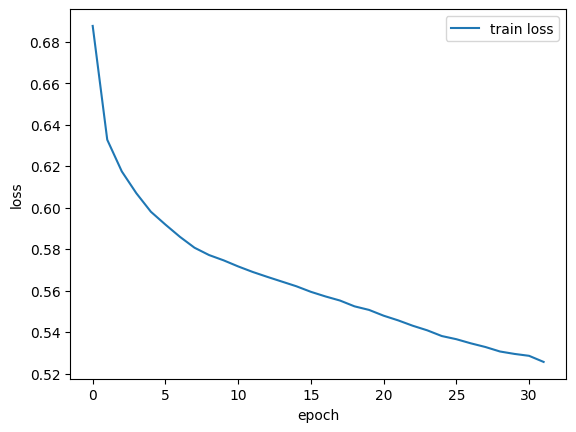

In [125]:
# 학습곡선, 학습이 제대로 이뤄지고 있다면 원점에 볼록한 그래프가 그려질 것이다.
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

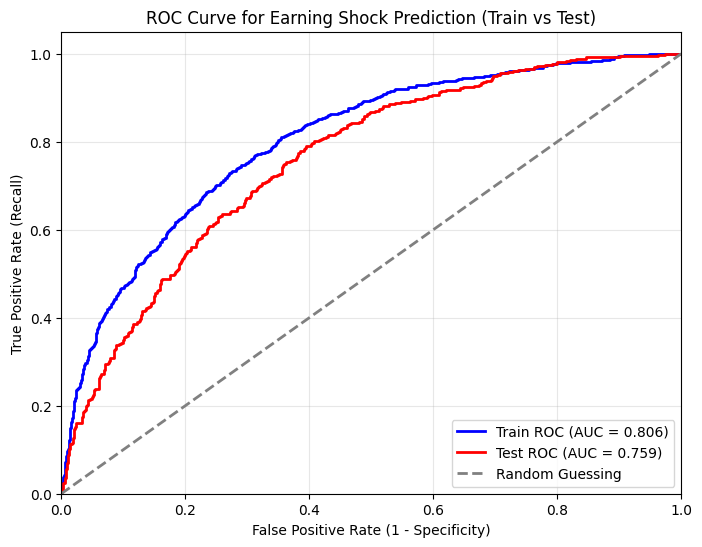

In [126]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### 라쏘로 변수 선택 후 MLP로 분류

In [127]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# 1. 라쏘(L1 Logistic)를 위한 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# 2. 라쏘(Lasso) 기반 변수 선택
# C값이 작을수록 규제가 강해지며, 더 많은 변수의 가중치를 0으로 만듭니다.
lasso_model = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# 가중치가 0이 아닌 변수들만 추출
lasso_selected_mask = lasso_model.coef_[0] != 0
final_selected_features = X_train.columns[lasso_selected_mask].tolist()

print(f"--- Lasso (L1) 선택 변수 개수: {len(final_selected_features)} ---")
print(final_selected_features)

# 이후 MLP 학습에서 top_features 대신 final_selected_features를 사용하도록 갱신
top_features_lasso = final_selected_features
df = merged_df

--- Lasso (L1) 선택 변수 개수: 33 ---
['자기자본비율', '비유동장기적합률', '유동부채비율', '비유동부채비율', '순운전자본비율', '유보율', '자본금대비자본총계비율', '단기부채의존도', '장기부채의존도', '총자산회전율', '자기자본회전율', '유동자산회전율', '비유동자산회전율', '타인자본회전율', '유동비율_YoY', '부채비율_YoY', '자기자본비율_YoY', '총부채의존도_YoY', '비유동비율_YoY', '비유동장기적합률_YoY', '유보율_YoY', '자본금대비자본총계비율_YoY', '단기부채의존도_YoY', '장기부채의존도_YoY', '총자산회전율_YoY', '자기자본회전율_YoY', '유동자산회전율_YoY', '비유동자산회전율_YoY', '순운전자본회전율_YoY', '타인자본회전율_YoY', '비유동부채', '비유동자산', '자본금']


In [128]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_lasso]
y_train = train_df['earning_shock']

X_test = test_df[top_features_lasso]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
0    1884
1     957
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    1884
1    1884
Name: count, dtype: int64


In [129]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred))

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정
current_sector = 'car'
current_method = 'lasso_mlp'

# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.6916192885297838
              precision    recall  f1-score   support

           0       0.83      0.77      0.80      1147
           1       0.40      0.50      0.45       355

    accuracy                           0.71      1502
   macro avg       0.62      0.64      0.62      1502
weighted avg       0.73      0.71      0.72      1502

[car] 섹터의 [lasso_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 car에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [130]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.837 | F1(클래스1): 0.745
[TEST] AUC: 0.692 | F1(클래스1): 0.447

AUC 격차(train - test): 0.146


In [131]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC: 0.513 ± 0.026


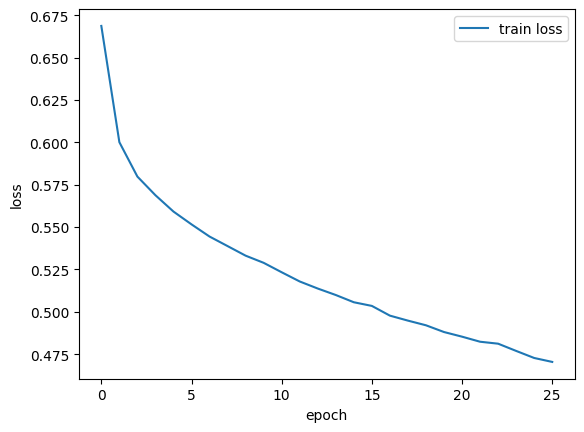

In [132]:
# 학습곡선
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

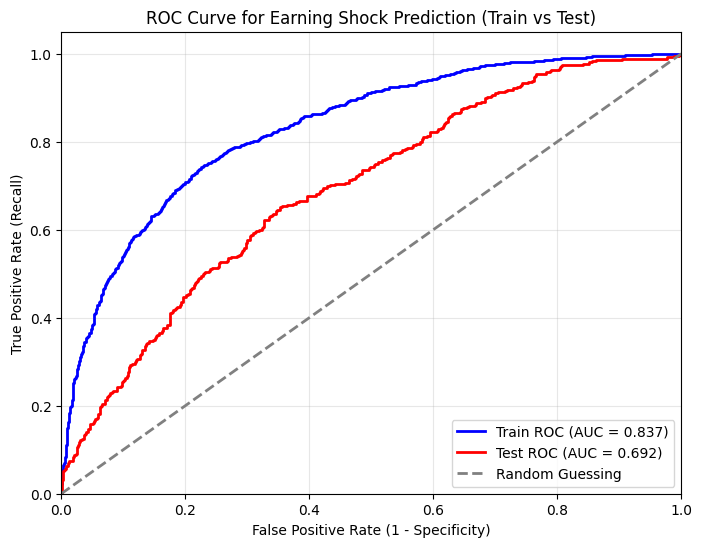

In [133]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### XGBoost를 이용한 분류

In [134]:
"""
MLP(신경망)는 이미지나 텍스트 같은 비정형 데이터에서는 강력하지만, 재무비율처럼 변수 간의 스케일이 다르고 극단치(Outlier)가 많은 데이터에서는 학습이 까다롭습니다. 반면 XGBoost는 트리 기반이므로 스케일링이나 아웃라이어에 훨씬 강건(Robust)합니다.

981:337의 데이터 불균형 문제를 SMOTE나 복잡한 구현 없이 파라미터 단 한 줄(scale_pos_weight) 로 해결할 수 있다. XGBoost는 태생적으로 비용 민감 학습(Cost-sensitive learning)을 지원.

XGBoost는 자체적으로 강력한 Feature Importance를 제공하므로, 라쏘로 선택한 변수들 중에서도 어떤 재무비율이 가장 결정적인 역할을 했는지 발표 때 시각화해서 보여주기 매우 좋습니다.
"""

'\nMLP(신경망)는 이미지나 텍스트 같은 비정형 데이터에서는 강력하지만, 재무비율처럼 변수 간의 스케일이 다르고 극단치(Outlier)가 많은 데이터에서는 학습이 까다롭습니다. 반면 XGBoost는 트리 기반이므로 스케일링이나 아웃라이어에 훨씬 강건(Robust)합니다.\n\n981:337의 데이터 불균형 문제를 SMOTE나 복잡한 구현 없이 파라미터 단 한 줄(scale_pos_weight) 로 해결할 수 있다. XGBoost는 태생적으로 비용 민감 학습(Cost-sensitive learning)을 지원.\n\nXGBoost는 자체적으로 강력한 Feature Importance를 제공하므로, 라쏘로 선택한 변수들 중에서도 어떤 재무비율이 가장 결정적인 역할을 했는지 발표 때 시각화해서 보여주기 매우 좋습니다.\n'

In [135]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

In [136]:
# 2. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = merged_df[merged_df['period'] <= '2022Q4'].copy()
test_df = merged_df[merged_df['period'] >= '2023Q1'].copy()

# 전체 변수(features)를 그대로 투입
X_train = train_df[features]
y_train = train_df['earning_shock']

X_test = test_df[features]
y_test = test_df['earning_shock']

# 3. 결측치 존재 여부 확인 및 제거 (기존 로직 유지)
# 참고: XGBoost는 결측치를 자체적으로(내부적으로) 처리할 수 있는 능력이 있지만,
# 데이터의 깔끔한 통제를 위해 기존 작성하신 dropna 로직을 유지하는 것도 좋은 방법입니다.
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    # 나중에 파마-프렌치 검증에 사용할 test_df의 인덱스도 동일하게 맞춰줍니다.
    test_df = test_df.loc[non_nan_indices_test]

# 4. 스케일링 생략 (XGBoost 특성 반영)
# 트리 모델이므로 StandardScaler가 필요 없습니다. 다음 단계 모델링에 바로 사용할 수 있도록 변수명만 정리합니다.
X_train_final = X_train.copy()
X_test_final = X_test.copy()

print(f"X_train shape: {X_train_final.shape}, y_train 어닝쇼크 개수: {y_train.sum()}")
print(f"X_test shape: {X_test_final.shape}, y_test 어닝쇼크 개수: {y_test.sum()}")

X_train shape: (2841, 47), y_train 어닝쇼크 개수: 957
X_test shape: (1502, 47), y_test 어닝쇼크 개수: 355


In [137]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 2. 불균형 데이터 처리를 위한 가중치 계산 (정상 981개 / 쇼크 337개 = 약 2.91)
# 어닝 쇼크(1)를 틀렸을 때의 벌점을 약 3배로 세팅하여 민감도를 높입니다.
imbalance_ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# 3. XGBoost 모델 정의 및 학습
xgb_model_all = xgb.XGBClassifier(
    n_estimators=200,            # 전체 변수를 탐색해야 하므로 나무 개수를 여유 있게 줍니다.
    learning_rate=0.05,
    max_depth=3,                 # 변수가 많으므로 너무 깊어지면 과적합됩니다 (4~5 권장)
    colsample_bytree=0.8,        # 핵심: 나무를 만들 때마다 전체 변수의 80%만 랜덤하게 뽑아서 씁니다. (자체적인 노이즈 필터링 효과)
    scale_pos_weight=imbalance_ratio,
    min_child_weight=3,
    gamma=0.3, # 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값, 해당 값보다 큰 손실(loss)이 감소된 경우 리프 노드를 분리하며 값이 클수록 과적합 감소 효과가 있다.
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50 # 훈련에서 과적합 되는 걸 기 위해
)

# 전체 데이터를 넣고 학습 시작
xgb_model_all.fit(X_train_final, y_train, eval_set=[(X_test_final, y_test)], verbose=100)

# 4. 예측 및 성능 평가
y_pred_all = xgb_model_all.predict(X_test_final)

print("--- 전체 변수 투입 XGBoost 분류 성능 ---")
# ROC-AUC는 불균형 데이터에서 모델의 진정한 분류 능력을 보여주는 핵심 지표입니다.
print("ROC-AUC:", roc_auc_score(y_test, xgb_model_all.predict_proba(X_test_final)[:, 1]))
print(classification_report(y_test, y_pred_all))

# 5. XGBoost가 자체적으로 솎아낸 '진짜 중요한 변수' 확인
importances = pd.Series(xgb_model_all.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- XGBoost 자체 판단 중요 변수 Top 10 ---")
print(importances.head(10))

# 6. 파마-프렌치 팩터 모형용 '어닝 팩터(확률)' 추출
test_df['earning_factor'] = xgb_model_all.predict_proba(X_test_final)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'car'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'xgboost'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

[0]	validation_0-auc:0.76216
[53]	validation_0-auc:0.80920
--- 전체 변수 투입 XGBoost 분류 성능 ---
ROC-AUC: 0.8116789665631101
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1147
           1       0.51      0.59      0.55       355

    accuracy                           0.77      1502
   macro avg       0.69      0.71      0.70      1502
weighted avg       0.78      0.77      0.77      1502


--- XGBoost 자체 판단 중요 변수 Top 10 ---
유보율_YoY            0.161267
자본금대비자본총계비율_YoY    0.070327
자본금대비자본총계비율        0.042074
단기부채의존도            0.038261
유보율                0.037663
비유동장기적합률           0.036537
유동부채비율             0.032742
타인자본회전율            0.032012
총부채의존도             0.027330
비유동비율_YoY          0.026999
dtype: float32
[car] 섹터의 [xgboost] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 car에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


In [138]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)
train_auc = evaluate(xgb_model_all, X_train_final, y_train, name="TRAIN")
test_auc  = evaluate(xgb_model_all, X_test_final,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")
print(f"\n[최적 조기 종료 지점: {xgb_model_all.best_iteration} 번째 트리]")

[TRAIN] AUC: 0.849 | F1(클래스1): 0.692
[TEST] AUC: 0.812 | F1(클래스1): 0.548

AUC 격차(train - test): 0.037

[최적 조기 종료 지점: 3 번째 트리]


In [139]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_train, y_train, X_test, y_test, train_auc, test_auc):
    # 1. 1(어닝쇼크)이 될 확률 추출
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    # 2. FPR(거짓 양성 비율), TPR(참 양성 비율) 계산
    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    # 3. 그래프 그리기
    plt.figure(figsize=(8, 6))

    # Train ROC
    plt.plot(fpr_train, tpr_train, color='blue', lw=2,
             label=f'Train ROC (AUC = {train_auc:.3f})')

    # Test ROC
    plt.plot(fpr_test, tpr_test, color='red', lw=2,
             label=f'Test ROC (AUC = {test_auc:.3f})')

    # 무작위 추측 선 (Random Guessing, AUC 0.5)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

    # 그래프 꾸미기
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve for Earning Shock Prediction (Train vs Test)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # 출력
    plt.show()

In [140]:
"""
2. Specificity (특이도)란 무엇인가?
머신러닝에서 '특이도'는 "실제 정상(0)인 기업들 중에서, 모델이 정상(0)이라고 올바르게 맞춘 비율"을 의미합니다.

예를 들어, 실제 정상 기업이 100개인데 모델이 그중 80개를 "정상입니다!"라고 잘 맞췄다면 특이도는 0.8 (80%)이 됩니다.

3. 그렇다면 '1 - Specificity'는 무엇인가? (핵심)
특이도가 '잘 맞춘 비율'이라면, 1에서 특이도를 뺀 1 - Specificity는 '틀린 비율'이 됩니다. 이를 머신러닝에서는 FPR (False Positive Rate, 거짓 양성 비율)이라고 부릅니다.

FPR (1 - 특이도): 실제로는 정상(0) 기업인데, 모델이 "어닝 쇼크(1)다!!!" 라고 잘못 짚은(오경보를 울린) 비율입니다.

방금 전 예시에서 정상 기업 100개 중 80개를 맞췄으니(특이도 80%), 나머지 20개는 억울하게 쇼크 판정을 받았겠죠? 이때의 1 - Specificity는 0.2 (20%)가 됩니다.

4. 왜 하필 ROC 커브의 X축에 오경보 비율(1-특이도)을 쓸까?
이유는 '트레이드오프(Trade-off)' 관계를 시각적으로 보기 위해서입니다.

어닝 쇼크를 단 한 개도 놓치지 않고 100% 다 잡아내려면(Recall을 1.0으로 만들려면) 어떻게 하면 될까요? 가장 무식하고 쉬운 방법은 "모든 기업이 다 어닝 쇼크다!"라고 찍어버리는 것입니다.
하지만 이렇게 하면 실제 정상인 기업들까지 전부 쇼크라고 오해하게 되므로, 오경보 비율(1-특이도)도 100%로 치솟게 됩니다. * Y축 (Recall, 재현율): 실제 쇼크 중에 모델이 쇼크라고 잘 잡아낸 비율 (높을수록 좋음)

X축 (1-Specificity, 오경보 비율): 정상인데 쇼크라고 억울하게 오해받은 비율 (낮을수록 좋음)

결국 ROC 커브는 "오경보(X축)를 많이 내지 않으면서도, 진짜 쇼크(Y축)를 얼마나 쏙쏙 잘 골라내는가?"를 보여주는 가성비 그래프입니다. 그래서 곡선이 왼쪽 위 모서리(오경보는 0에 가깝고, 쇼크 적중률은 1에 가까운 상태)로 착 달라붙을수록 성능이 좋은 모델이라고 평가하는 것입니다.
"""

'\n2. Specificity (특이도)란 무엇인가?\n머신러닝에서 \'특이도\'는 "실제 정상(0)인 기업들 중에서, 모델이 정상(0)이라고 올바르게 맞춘 비율"을 의미합니다.\n\n예를 들어, 실제 정상 기업이 100개인데 모델이 그중 80개를 "정상입니다!"라고 잘 맞췄다면 특이도는 0.8 (80%)이 됩니다.\n\n3. 그렇다면 \'1 - Specificity\'는 무엇인가? (핵심)\n특이도가 \'잘 맞춘 비율\'이라면, 1에서 특이도를 뺀 1 - Specificity는 \'틀린 비율\'이 됩니다. 이를 머신러닝에서는 FPR (False Positive Rate, 거짓 양성 비율)이라고 부릅니다.\n\nFPR (1 - 특이도): 실제로는 정상(0) 기업인데, 모델이 "어닝 쇼크(1)다!!!" 라고 잘못 짚은(오경보를 울린) 비율입니다.\n\n방금 전 예시에서 정상 기업 100개 중 80개를 맞췄으니(특이도 80%), 나머지 20개는 억울하게 쇼크 판정을 받았겠죠? 이때의 1 - Specificity는 0.2 (20%)가 됩니다.\n\n4. 왜 하필 ROC 커브의 X축에 오경보 비율(1-특이도)을 쓸까?\n이유는 \'트레이드오프(Trade-off)\' 관계를 시각적으로 보기 위해서입니다.\n\n어닝 쇼크를 단 한 개도 놓치지 않고 100% 다 잡아내려면(Recall을 1.0으로 만들려면) 어떻게 하면 될까요? 가장 무식하고 쉬운 방법은 "모든 기업이 다 어닝 쇼크다!"라고 찍어버리는 것입니다.\n하지만 이렇게 하면 실제 정상인 기업들까지 전부 쇼크라고 오해하게 되므로, 오경보 비율(1-특이도)도 100%로 치솟게 됩니다. * Y축 (Recall, 재현율): 실제 쇼크 중에 모델이 쇼크라고 잘 잡아낸 비율 (높을수록 좋음)\n\nX축 (1-Specificity, 오경보 비율): 정상인데 쇼크라고 억울하게 오해받은 비율 (낮을수록 좋음)\n\n결국 ROC 커브는 "오경보(X축)를 많이 내지 않으면서도, 진짜 쇼크(Y축)를 얼마나 쏙쏙 잘 골라내는가?"를 

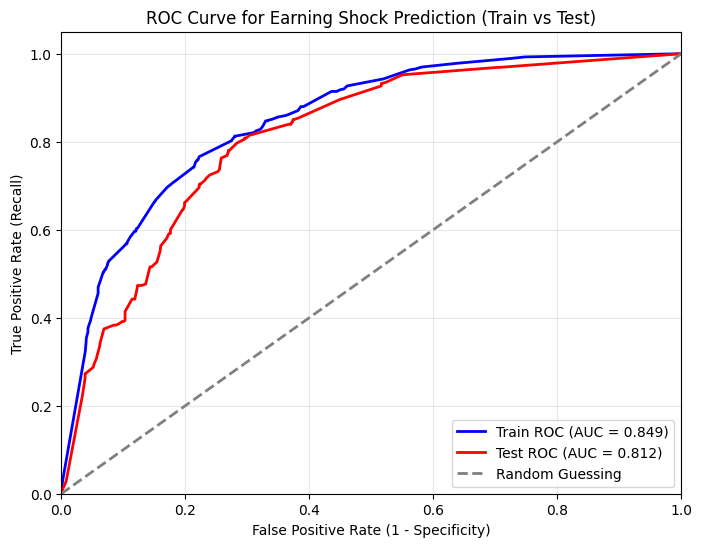

In [141]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(xgb_model_all, X_train_final, y_train, X_test_final, y_test, train_auc, test_auc)

## 반도체 업종

In [142]:
semi_acnt_filled = pd.read_csv(file_path2['semi_acnt'])
semi_indx_filled = pd.read_csv(file_path2['semi_indx'])

In [143]:
# car_indx.isnull().sum()

In [144]:
# acnt 데이터에 라벨 설정 (Z-스코어를 이용한 어닝 쇼크 라벨링)
semi_acnt_labeled = create_label_by_size_group(semi_acnt_filled.copy(), '당기순이익(손실)')

# 두 데이터프레임 간에 겹치는 칼럼이 무엇인지 자동 탐색(indx의 결측치를 채우는 과정에서 acnt의 칼럼들이 indx에도 포함되어서 중복이 발생)
# (조인 키인 'corp_code'와 'period'는 겹쳐야 하므로 제외)
common_cols = set(semi_indx_filled.columns) & set(semi_acnt_labeled.columns)
overlap_cols = [c for c in common_cols if c not in ['corp_code', 'period']]

print("indx와 acnt 양쪽에 존재하는 중복 칼럼들:", overlap_cols)

# 2. acnt와 indx 테이블 병합 (indx 쪽에서 중복 칼럼을 미리 Drop!)
merged_df = pd.merge(
    semi_indx_filled.drop(columns=overlap_cols), # _x가 생기지 않도록 미리 제거
    semi_acnt_labeled,
    on=['corp_code', 'period'],
    how='inner'
)

# 3. 피처 선택 및 RF 혙식 데이터 분리
exclude_cols = [
    'corp_code', 'stock_code', 'period', '당기순이익(손실)', 'earning_shock', 'z_score_size', 'size_group',
    '순이익', 'ROE', '납입자본이익률', '매출총이익률', '순이익률', '총포괄이익률', '매출총이익률', '자본금영업이익률', '총자산영업이익률',
    '법인세차감전 순이익', '영업이익', '매출액', '자기자본영업이익률'
]
features = [c for c in merged_df.columns if c not in exclude_cols]

indx와 acnt 양쪽에 존재하는 중복 칼럼들: []


In [145]:
features

['유동비율',
 '부채비율',
 '자기자본비율',
 '총부채의존도',
 '비유동비율',
 '비유동장기적합률',
 '유동부채비율',
 '비유동부채비율',
 '순운전자본비율',
 '유보율',
 '자본금대비자본총계비율',
 '단기부채의존도',
 '장기부채의존도',
 '총자산회전율',
 '자기자본회전율',
 '유동자산회전율',
 '비유동자산회전율',
 '순운전자본회전율',
 '타인자본회전율',
 '유동비율_YoY',
 '부채비율_YoY',
 '자기자본비율_YoY',
 '총부채의존도_YoY',
 '비유동비율_YoY',
 '비유동장기적합률_YoY',
 '유동부채비율_YoY',
 '비유동부채비율_YoY',
 '순운전자본비율_YoY',
 '유보율_YoY',
 '자본금대비자본총계비율_YoY',
 '단기부채의존도_YoY',
 '장기부채의존도_YoY',
 '총자산회전율_YoY',
 '자기자본회전율_YoY',
 '유동자산회전율_YoY',
 '비유동자산회전율_YoY',
 '순운전자본회전율_YoY',
 '타인자본회전율_YoY',
 '부채총계',
 '비유동부채',
 '비유동자산',
 '유동부채',
 '유동자산',
 '이익잉여금',
 '자본금',
 '자본총계',
 '자산총계']

In [146]:
merged_df['earning_shock'].value_counts()
# car_indx_labeled['earning_shock'].value_counts()

,count
earning_shock,
0,2945
1,1051


### 랜덤포레스트로 변수 선택 후 MLP로 분류

In [147]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---")
print(importances.head(15))

top_features_rf = importances.head(10).index.tolist()
df = merged_df

--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---
유보율_YoY            0.096880
자본금대비자본총계비율_YoY    0.070109
유보율                0.044086
유동자산               0.043476
이익잉여금              0.043080
타인자본회전율            0.029844
자본금대비자본총계비율        0.028889
자본총계               0.024567
총자산회전율             0.022490
자산총계               0.022141
비유동자산              0.021395
타인자본회전율_YoY        0.021208
비유동자산회전율           0.019869
유동자산회전율            0.019742
비유동비율_YoY          0.018442
dtype: float64


In [148]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_rf]
y_train = train_df['earning_shock']

X_test = test_df[top_features_rf]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
0    1678
1     421
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    1678
1    1678
Name: count, dtype: int64


In [149]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred)) # 테스트 결과를 출력

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'semi'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'rf_mlp'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.7989292188969354
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       876
           1       0.58      0.75      0.65       471

    accuracy                           0.72      1347
   macro avg       0.71      0.73      0.71      1347
weighted avg       0.75      0.72      0.73      1347

[semi] 섹터의 [rf_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 semi에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [150]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.836 | F1(클래스1): 0.773
[TEST] AUC: 0.799 | F1(클래스1): 0.652

AUC 격차(train - test): 0.037


In [151]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC: 0.626 ± 0.048


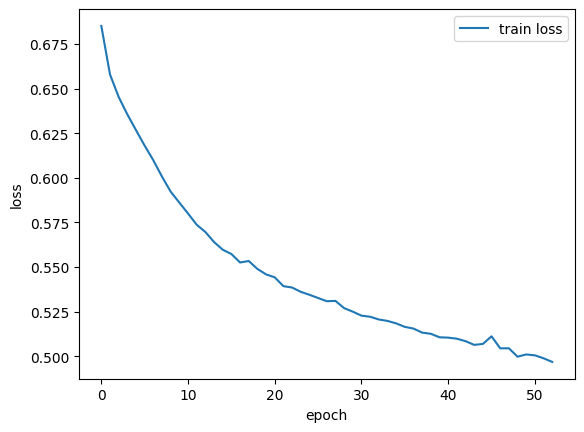

In [152]:
# 학습곡선
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

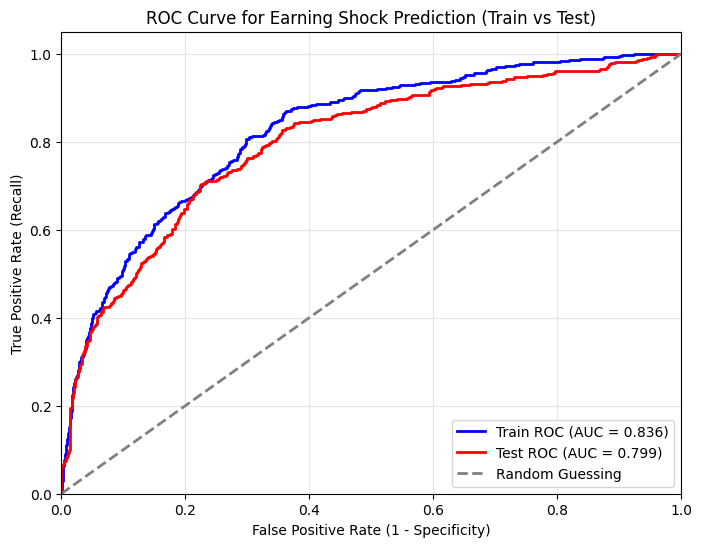

In [153]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### 라쏘로 변수 선택 후 MLP로 분류

In [154]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# 1. 라쏘(L1 Logistic)를 위한 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# 2. 라쏘(Lasso) 기반 변수 선택
# C값이 작을수록 규제가 강해지며, 더 많은 봀수의 가중치를 0으로 만듭니다.
lasso_model = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# 가중치가 0이 아닌 봀수들만 추출
lasso_selected_mask = lasso_model.coef_[0] != 0
final_selected_features = X_train.columns[lasso_selected_mask].tolist()

print(f"--- Lasso (L1) 선택 변수 개수: {len(final_selected_features)} ---")
print(final_selected_features)

# 이후 MLP 학습에서 top_features 대신 final_selected_features를 사용하도록 갱신
top_features_lasso = final_selected_features
df = merged_df

--- Lasso (L1) 선택 변수 개수: 31 ---
['유동비율', '자기자본비율', '비유동비율', '비유동장기적합률', '비유동부채비율', '순운전자본비율', '자본금대비자본총계비율', '단기부채의존도', '장기부채의존도', '자기자본회전율', '유동자산회전율', '비유동자산회전율', '순운전자본회전율', '타인자본회전율', '유동비율_YoY', '부채비율_YoY', '자기자본비율_YoY', '비유동비율_YoY', '비유동장기적합률_YoY', '비유동부채비율_YoY', '순운전자본비율_YoY', '유보율_YoY', '자본금대비자본총계비율_YoY', '단기부채의존도_YoY', '총자산회전율_YoY', '자기자본회전율_YoY', '유동자산회전율_YoY', '비유동자산회전율_YoY', '순운전자본회전율_YoY', '타인자본회전율_YoY', '자본금']


In [155]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_lasso]
y_train = train_df['earning_shock']

X_test = test_df[top_features_lasso]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
0    1676
1     421
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    1676
1    1676
Name: count, dtype: int64


In [156]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred))

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'semi'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'lasso_mlp'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.7038822480101601
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       876
           1       0.57      0.52      0.54       471

    accuracy                           0.69      1347
   macro avg       0.66      0.65      0.66      1347
weighted avg       0.69      0.69      0.69      1347

[semi] 섹터의 [lasso_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 semi에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [157]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.900 | F1(클래스1): 0.827
[TEST] AUC: 0.704 | F1(클래스1): 0.542

AUC 격차(train - test): 0.196


In [158]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC: 0.500 ± 0.000


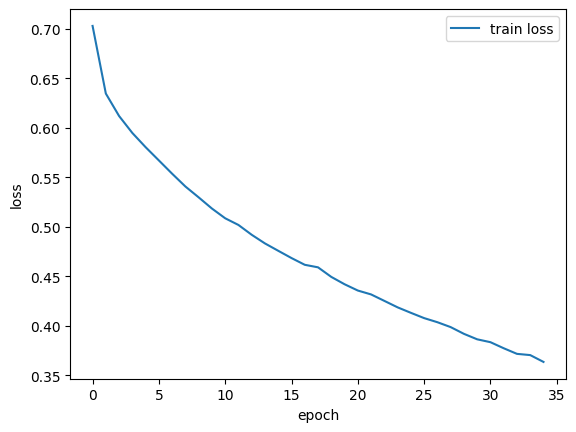

In [159]:
# 학습곡선
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

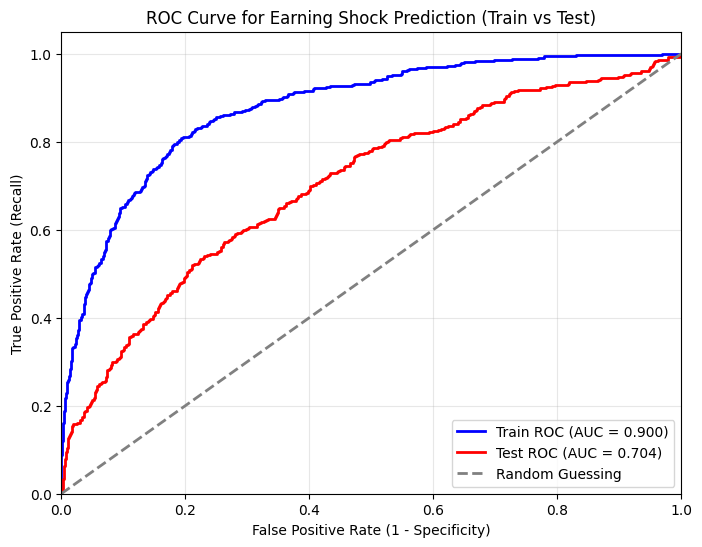

In [160]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### XGBoost를 이용한 분류

In [161]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

In [162]:
# 2. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = merged_df[merged_df['period'] <= '2022Q4'].copy()
test_df = merged_df[merged_df['period'] >= '2023Q1'].copy()

# 전체 변수(features)를 그대로 투입
X_train = train_df[features]
y_train = train_df['earning_shock']

X_test = test_df[features]
y_test = test_df['earning_shock']

# 3. 결측치 존재 여부 확인 및 제거 (기존 로직 유지)
# 참고: XGBoost는 결측치를 자체적으로(내부적으로) 처리할 수 있는 능력이 있지만,
# 데이터의 깔끔한 통제를 위해 기존 작성하신 dropna 로직을 유지하는 것도 좋은 방법입니다.
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    # 나중에 파마-프렌치 검증에 사용할 test_df의 인덱스도 동일하게 맞춰줍니다.
    test_df = test_df.loc[non_nan_indices_test]

# 4. 스케일링 생략 (XGBoost 특성 반영)
# 트리 모델이므로 StandardScaler가 필요 없습니다. 다음 단계 모델링에 바로 사용할 수 있도록 변수명만 정리합니다.
X_train_final = X_train.copy()
X_test_final = X_test.copy()

print(f"X_train shape: {X_train_final.shape}, y_train 어닝쇼크 개수: {y_train.sum()}")
print(f"X_test shape: {X_test_final.shape}, y_test 어닝쇼크 개수: {y_test.sum()}")

X_train shape: (2097, 47), y_train 어닝쇼크 개수: 421
X_test shape: (1347, 47), y_test 어닝쇼크 개수: 471


In [163]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 2. 불균형 데이터 처리를 위한 가중치 계산 (정상 981개 / 쇼크 337개 = 약 2.91)
# 어닝 쇼크(1)를 틀렸을 때의 벌점을 약 3배로 세팅하여 민감도를 높입니다.
imbalance_ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# 3. XGBoost 모델 정의 및 학습
xgb_model_all = xgb.XGBClassifier(
    n_estimators=300,            # 전체 변수를 탐색해야 하므로 나무 개수를 여유 있게 줍니다.
    learning_rate=0.05,
    max_depth=4,                 # 변수가 많으므로 너무 깊어지면 과적합됩니다 (4~5 권장)
    colsample_bytree=0.8,        # 핵심: 나무를 만들 때마다 전체 변수의 80%만 랜덤하게 뽑아서 씁니다. (자체적인 노이즈 필터링 효과)
    scale_pos_weight=imbalance_ratio,
    min_child_weight=3,
    gamma=0.3, # 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값, 해당 값보다 큰 손실(loss)이 감소된 경우 리프 노드를 분리하며 값이 클수록 과적합 감소 효과가 있다.
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50 # 훈련에서 과적합 되는 걸 기 위해
)

# 전체 데이터를 넣고 학습 시작
xgb_model_all.fit(X_train_final, y_train, eval_set=[(X_test_final, y_test)], verbose=100)

# 4. 예측 및 성능 평가
y_pred_all = xgb_model_all.predict(X_test_final)

print("--- 전체 변수 투입 XGBoost 분류 성능 ---")
# ROC-AUC는 불균형 데이터에서 모델의 진정한 분류 능력을 보여주는 핵심 지표입니다.
print("ROC-AUC:", roc_auc_score(y_test, xgb_model_all.predict_proba(X_test_final)[:, 1]))
print(classification_report(y_test, y_pred_all))

# 5. XGBoost가 자체적으로 솎아낸 '진짜 중요한 변수' 확인
importances = pd.Series(xgb_model_all.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- XGBoost 자체 판단 중요 변수 Top 10 ---")
print(importances.head(10))

# 6. 파마-프렌치 팩터 모형용 '어닝 팩터(확률)' 추출
test_df['earning_factor'] = xgb_model_all.predict_proba(X_test_final)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'semi'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'xgboost'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

[0]	validation_0-auc:0.79875
[100]	validation_0-auc:0.85575
[114]	validation_0-auc:0.85501
--- 전체 변수 투입 XGBoost 분류 성능 ---
ROC-AUC: 0.8609826561575972
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       876
           1       0.72      0.68      0.70       471

    accuracy                           0.80      1347
   macro avg       0.78      0.77      0.77      1347
weighted avg       0.80      0.80      0.80      1347


--- XGBoost 자체 판단 중요 변수 Top 10 ---
유보율_YoY            0.158763
유동자산               0.040541
자본금대비자본총계비율_YoY    0.038892
자본총계               0.037833
총자산회전율             0.035348
비유동자산회전율           0.035161
이익잉여금              0.034949
자산총계               0.026955
유동비율               0.024286
자기자본비율             0.023587
dtype: float32
[semi] 섹터의 [xgboost] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 semi에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


In [164]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)
train_auc = evaluate(xgb_model_all, X_train_final, y_train, name="TRAIN")
test_auc  = evaluate(xgb_model_all, X_test_final,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")
print(f"\n[최적 조기 종료 지점: {xgb_model_all.best_iteration} 번째 트리]")

[TRAIN] AUC: 0.970 | F1(클래스1): 0.789
[TEST] AUC: 0.861 | F1(클래스1): 0.702

AUC 격차(train - test): 0.109

[최적 조기 종료 지점: 64 번째 트리]


In [165]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_train, y_train, X_test, y_test, train_auc, test_auc):
    # 1. 1(어닝쇼크)이 될 확률 추출
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    # 2. FPR(거짓 양성 비율), TPR(참 양성 비율) 계산
    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    # 3. 그래프 그리기
    plt.figure(figsize=(8, 6))

    # Train ROC
    plt.plot(fpr_train, tpr_train, color='blue', lw=2,
             label=f'Train ROC (AUC = {train_auc:.3f})')

    # Test ROC
    plt.plot(fpr_test, tpr_test, color='red', lw=2,
             label=f'Test ROC (AUC = {test_auc:.3f})')

    # 무작위 추측 선 (Random Guessing, AUC 0.5)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

    # 그래프 꾸미기
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve for Earning Shock Prediction (Train vs Test)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # 출력
    plt.show()

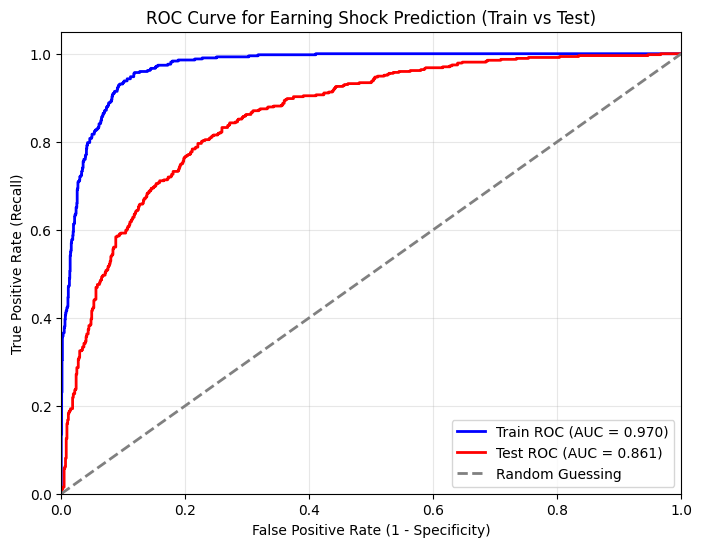

In [166]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
plot_roc_curve(xgb_model_all, X_train_final, y_train, X_test_final, y_test, train_auc, test_auc)

## 조선 업종

In [167]:
ship_acnt_filled = pd.read_csv(file_path2['ship_acnt'])
ship_indx_filled = pd.read_csv(file_path2['ship_indx'])

In [168]:
# car_indx.isnull().sum()

In [169]:
# acnt 데이터에 라벨 설정 (Z-스코어를 이용한 어닝 쇼크 라벨링)
ship_acnt_labeled = create_label_by_size_group(ship_acnt_filled.copy(), '당기순이익(손실)')

# 두 데이터프레임 간에 겹치는 칼럼이 무엇인지 자동 탐색(indx의 결측치를 채우는 과정에서 acnt의 칼럼들이 indx에도 포함되어서 중복이 발생)
# (조인 키인 'corp_code'와 'period'는 겹쳐야 하므로 제외)
common_cols = set(ship_indx_filled.columns) & set(ship_acnt_labeled.columns)
overlap_cols = [c for c in common_cols if c not in ['corp_code', 'period']]

print("indx와 acnt 양쪽에 존재하는 중복 칼럼들:", overlap_cols)

# 2. acnt와 indx 테이블 병합 (indx 쪽에서 중복 칼럼을 미리 Drop!)
merged_df = pd.merge(
    ship_indx_filled.drop(columns=overlap_cols), # _x가 생기지 않도록 미리 제거
    ship_acnt_labeled,
    on=['corp_code', 'period'],
    how='inner'
)

# 3. 피처 선택 및 RF 혙식 데이터 분리
exclude_cols = [
    'corp_code', 'stock_code', 'period', '당기순이익(손실)', 'earning_shock', 'z_score_size', 'size_group',
    '순이익', 'ROE', '납입자본이익률', '매출총이익률', '순이익률', '총포괄이익률', '매출총이익률', '자본금영업이익률', '총자산영업이익률',
    '법인세차감전 순이익', '영업이익', '매출액', '자기자본영업이익률'
]
features = [c for c in merged_df.columns if c not in exclude_cols]

indx와 acnt 양쪽에 존재하는 중복 칼럼들: []


In [170]:
features

['유동비율',
 '부채비율',
 '자기자본비율',
 '총부채의존도',
 '비유동비율',
 '비유동장기적합률',
 '유동부채비율',
 '비유동부채비율',
 '순운전자본비율',
 '유보율',
 '자본금대비자본총계비율',
 '단기부채의존도',
 '장기부채의존도',
 '총자산회전율',
 '자기자본회전율',
 '유동자산회전율',
 '비유동자산회전율',
 '순운전자본회전율',
 '타인자본회전율',
 '유동비율_YoY',
 '부채비율_YoY',
 '자기자본비율_YoY',
 '총부채의존도_YoY',
 '비유동비율_YoY',
 '비유동장기적합률_YoY',
 '유동부채비율_YoY',
 '비유동부채비율_YoY',
 '순운전자본비율_YoY',
 '유보율_YoY',
 '자본금대비자본총계비율_YoY',
 '단기부채의존도_YoY',
 '장기부채의존도_YoY',
 '총자산회전율_YoY',
 '자기자본회전율_YoY',
 '유동자산회전율_YoY',
 '비유동자산회전율_YoY',
 '순운전자본회전율_YoY',
 '타인자본회전율_YoY',
 '부채총계',
 '비유동부채',
 '비유동자산',
 '유동부채',
 '유동자산',
 '이익잉여금',
 '자본금',
 '자본총계',
 '자산총계']

In [171]:
merged_df['earning_shock'].value_counts()
# car_indx_labeled['earning_shock'].value_counts()

,count
earning_shock,
0,503
1,368


### 랜덤포레스트로 변수 선택 후 MLP로 분류

In [172]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print("--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---")
print(importances.head(15))

top_features_rf = importances.head(10).index.tolist()
df = merged_df

--- 병합 데이터셋 기반 밀수 중요도 (Top 15) ---
유보율_YoY            0.100837
유보율                0.081819
이익잉여금              0.044595
자본금대비자본총계비율_YoY    0.040516
자본금대비자본총계비율        0.036287
유동자산               0.033220
순운전자본비율            0.025027
자기자본비율_YoY         0.024983
타인자본회전율            0.023364
단기부채의존도            0.023342
순운전자본회전율           0.023196
장기부채의존도            0.021775
유동비율               0.020669
타인자본회전율_YoY        0.020637
자산총계               0.020255
dtype: float64


In [173]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_rf]
y_train = train_df['earning_shock']

X_test = test_df[top_features_rf]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
1    245
0    244
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    245
1    245
Name: count, dtype: int64


In [174]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred))

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'ship'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'rf_mlp'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.5769230769230769
              precision    recall  f1-score   support

           0       0.77      0.30      0.43       184
           1       0.32      0.79      0.46        78

    accuracy                           0.45       262
   macro avg       0.55      0.55      0.45       262
weighted avg       0.64      0.45      0.44       262

[ship] 섹터의 [rf_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 ship에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [175]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.675 | F1(클래스1): 0.704
[TEST] AUC: 0.577 | F1(클래스1): 0.461

AUC 격차(train - test): 0.098


In [176]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC: 0.638 ± 0.081


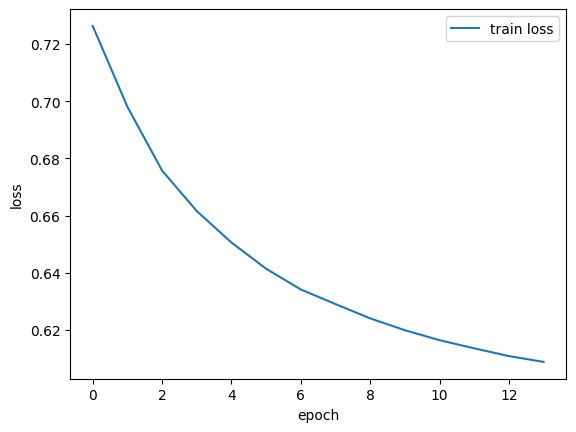

In [177]:
# 학습곡선
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

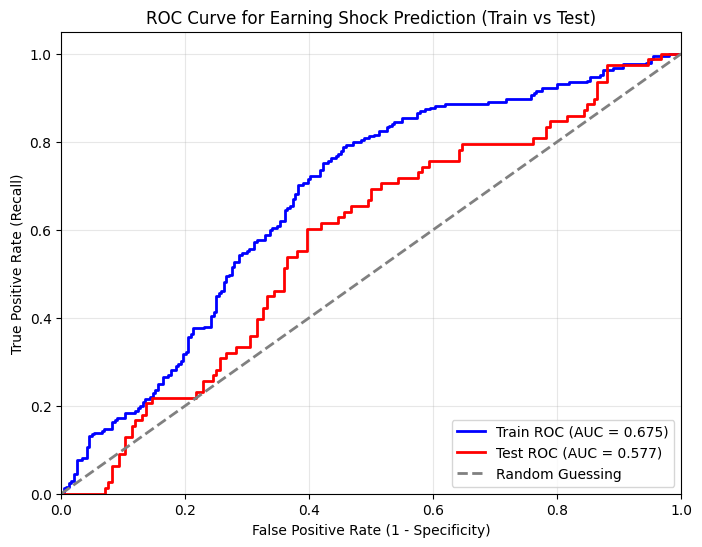

In [178]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### 라쏘로 변수 선택 후 MLP로 분류

In [179]:
train_df = merged_df[merged_df['period'] < '2022Q4'].dropna(subset=features + ['earning_shock'])

X_train = train_df[features]
y_train = train_df['earning_shock']

# 1. 라쏘(L1 Logistic)를 위한 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# 2. 라쏘(Lasso) 기반 변수 선택
# C값이 작을수록 규제가 강해지며, 더 많은 봀수의 가중치를 0으로 만듭니다.
lasso_model = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# 가중치가 0이 아닌 봀수들만 추출
lasso_selected_mask = lasso_model.coef_[0] != 0
final_selected_features = X_train.columns[lasso_selected_mask].tolist()

print(f"--- Lasso (L1) 선택 변수 개수: {len(final_selected_features)} ---")
print(final_selected_features)

# 이후 MLP 학습에서 top_features 대신 final_selected_features를 사용하도록 갱신
top_features_lasso = final_selected_features
df = merged_df

--- Lasso (L1) 선택 변수 개수: 27 ---
['총부채의존도', '비유동비율', '순운전자본비율', '유보율', '자본금대비자본총계비율', '장기부채의존도', '총자산회전율', '자기자본회전율', '유동자산회전율', '순운전자본회전율', '유동비율_YoY', '부채비율_YoY', '총부채의존도_YoY', '비유동부채비율_YoY', '순운전자본비율_YoY', '유보율_YoY', '자본금대비자본총계비율_YoY', '단기부채의존도_YoY', '총자산회전율_YoY', '유동자산회전율_YoY', '비유동자산회전율_YoY', '순운전자본회전율_YoY', '타인자본회전율_YoY', '부채총계', '이익잉여금', '자본금', '자본총계']


In [180]:
# 1. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = df[df['period'] <= '2022Q4'].copy()
test_df = df[df['period'] >= '2023Q1'].copy()

# MLP 학습을 위해 결측치가 있는 행을 최종적으로 제거 (중요 피처 기준)
X_train = train_df[top_features_lasso]
y_train = train_df['earning_shock']

X_test = test_df[top_features_lasso]
y_test = test_df['earning_shock']

# 결측치 존재 여부 확인 및 제거
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    test_df = test_df.loc[non_nan_indices_test]

# 2. MLP는 스케일에 매우 민감하므로 Standard Scaling 필수
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. SMOTE 객체 생성
smote = SMOTE(random_state=42)

# 2. 스케일링이 완료된 학습 데이터(X_train_scaled)에만 SMOTE 적용
# X_train_resampled와 y_train_resampled는 이제 0과 1의 개수가 981개로 1:1 비율이 됩니다.
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"SMOTE 적용 전: \n{y_train.value_counts()}")
print(f"SMOTE 적용 후: \n{y_train_resampled.value_counts()}")

SMOTE 적용 전: 
earning_shock
1    245
0    244
Name: count, dtype: int64
SMOTE 적용 후: 
earning_shock
0    245
1    245
Name: count, dtype: int64


In [181]:
# 3. MLP 구조 정의
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)

# 3. 모델 학습은 오버샘플링된 데이터로 진행
mlp.fit(X_train_resampled, y_train_resampled)

# 4. 예측 및 평가는 원본 형태를 유지한 테스트 데이터(X_test_scaled)로 진행
y_pred = mlp.predict(X_test_scaled)

print("--- MLP 모델 평가 ---")
print("ROC-AUC:", roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1]))
print(classification_report(y_test, y_pred))

# 4. '어닝 팩터(어닝 쇼크 확률)' 추출
test_df['earning_factor'] = mlp.predict_proba(X_test_scaled)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'ship'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'lasso_mlp'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

--- MLP 모델 평가 ---
ROC-AUC: 0.5422240802675585
              precision    recall  f1-score   support

           0       0.72      0.47      0.57       184
           1       0.31      0.56      0.40        78

    accuracy                           0.50       262
   macro avg       0.51      0.52      0.48       262
weighted avg       0.60      0.50      0.52       262

[ship] 섹터의 [lasso_mlp] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 ship에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


과적합 여부 검사

In [182]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)

train_auc = evaluate(mlp, X_train_resampled, y_train_resampled, name="TRAIN")
test_auc  = evaluate(mlp, X_test_scaled,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")

[TRAIN] AUC: 0.764 | F1(클래스1): 0.714
[TEST] AUC: 0.542 | F1(클래스1): 0.400

AUC 격차(train - test): 0.222


In [183]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV AUC: 0.638 ± 0.100


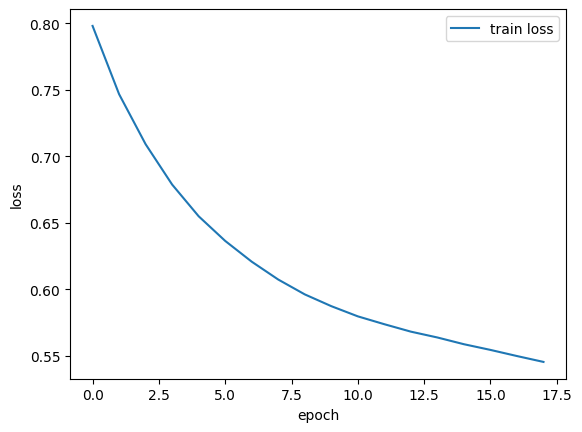

In [184]:
# 학습곡선
import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_, label='train loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.show()

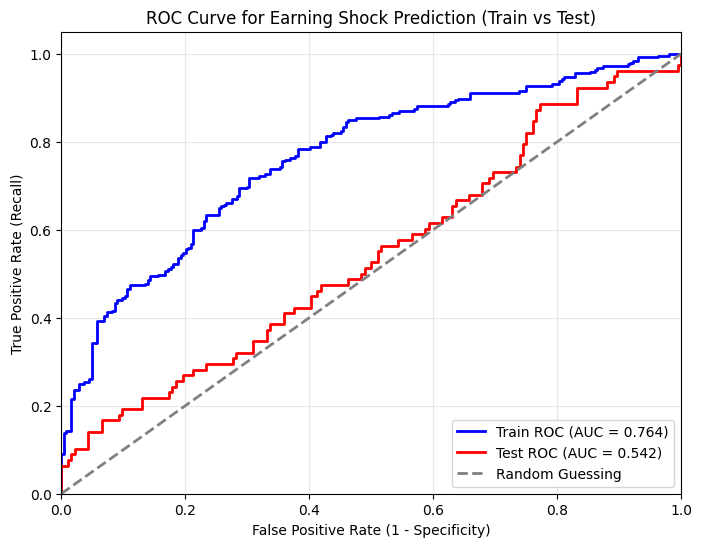

In [185]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
# 최종적인 성능
plot_roc_curve(mlp, X_train_scaled, y_train, X_test_scaled, y_test, train_auc, test_auc)

### XGBoost를 이용한 분류

In [186]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

In [187]:
# 2. 학습/테스트 데이터 분할 (시간 기준 OOT 분할)
train_df = merged_df[merged_df['period'] <= '2022Q4'].copy()
test_df = merged_df[merged_df['period'] >= '2023Q1'].copy()

# 전체 변수(features)를 그대로 투입
X_train = train_df[features]
y_train = train_df['earning_shock']

X_test = test_df[features]
y_test = test_df['earning_shock']

# 3. 결측치 존재 여부 확인 및 제거 (기존 로직 유지)
# 참고: XGBoost는 결측치를 자체적으로(내부적으로) 처리할 수 있는 능력이 있지만,
# 데이터의 깔끔한 통제를 위해 기존 작성하신 dropna 로직을 유지하는 것도 좋은 방법입니다.
if X_train.isnull().any().any():
    non_nan_indices = X_train.dropna().index
    X_train = X_train.loc[non_nan_indices]
    y_train = y_train.loc[non_nan_indices]

if X_test.isnull().any().any():
    non_nan_indices_test = X_test.dropna().index
    X_test = X_test.loc[non_nan_indices_test]
    y_test = y_test.loc[non_nan_indices_test]
    # 나중에 파마-프렌치 검증에 사용할 test_df의 인덱스도 동일하게 맞춰줍니다.
    test_df = test_df.loc[non_nan_indices_test]

# 4. 스케일링 생략 (XGBoost 특성 반영)
# 트리 모델이므로 StandardScaler가 필요 없습니다. 다음 단계 모델링에 바로 사용할 수 있도록 변수명만 정리합니다.
X_train_final = X_train.copy()
X_test_final = X_test.copy()

print(f"X_train shape: {X_train_final.shape}, y_train 어닝쇼크 개수: {y_train.sum()}")
print(f"X_test shape: {X_test_final.shape}, y_test 어닝쇼크 개수: {y_test.sum()}")

X_train shape: (489, 47), y_train 어닝쇼크 개수: 245
X_test shape: (262, 47), y_test 어닝쇼크 개수: 78


In [188]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 2. 불균형 데이터 처리를 위한 가중치 계산 (정상 981개 / 쇼크 337개 = 약 2.91)
# 어닝 쇼크(1)를 틀렸을 때의 벌점을 약 3배로 세팅하여 민감도를 높입니다.
imbalance_ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# 3. XGBoost 모델 정의 및 학습
xgb_model_all = xgb.XGBClassifier(
    n_estimators=200,            # 전체 변수를 탐색해야 하므로 나무 개수를 여유 있게 줍니다.
    learning_rate=0.05,
    max_depth=3,                 # 변수가 많으므로 너무 깊어지면 과적합됩니다 (4~5 권장)
    colsample_bytree=0.8,        # 핵심: 나무를 만들 때마다 전체 변수의 80%만 랜덤하게 뽑아서 씁니다. (자체적인 노이즈 필터링 효과)
    scale_pos_weight=imbalance_ratio,
    min_child_weight=3,
    gamma=0.3, # 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값, 해당 값보다 큰 손실(loss)이 감소된 경우 리프 노드를 분리하며 값이 클수록 과적합 감소 효과가 있다.
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50 # 훈련에서 과적합 되는 걸 기 위해
)

# 전체 데이터를 넣고 학습 시작
xgb_model_all.fit(X_train_final, y_train, eval_set=[(X_test_final, y_test)], verbose=100)

# 4. 예측 및 성능 평가
y_pred_all = xgb_model_all.predict(X_test_final)

print("--- 전체 변수 투입 XGBoost 분류 성능 ---")
# ROC-AUC는 불균형 데이터에서 모델의 진정한 분류 능력을 보여주는 핵심 지표입니다.
print("ROC-AUC:", roc_auc_score(y_test, xgb_model_all.predict_proba(X_test_final)[:, 1]))
print(classification_report(y_test, y_pred_all))

# 5. XGBoost가 자체적으로 솎아낸 '진짜 중요한 변수' 확인
importances = pd.Series(xgb_model_all.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- XGBoost 자체 판단 중요 변수 Top 10 ---")
print(importances.head(10))

# 6. 파마-프렌치 팩터 모형용 '어닝 팩터(확률)' 추출
test_df['earning_factor'] = xgb_model_all.predict_proba(X_test_final)[:, 1]

# 현재 작업 중인 섹터와 방법론을 지정합니다. (작업하실 때마다 이 문자열만 수정하세요!)
current_sector = 'ship'       # 'car', 'semi', 'ship' 중 택 1
current_method = 'xgboost'    # 'rf_mlp', 'lasso_mlp', 'xgboost' 중 택 1

# [수정] earning_results에 저장할 때 period를 인덱스로 설정하여 저장
# 이렇게 하면 나중에 merge 시 'period'를 키로 사용할 수 있습니다.
# [수정] earning_results에 period를 인덱스로 하여, corp_code와 earning_factor를 함께 저장
earning_results[current_sector][current_method] = test_df.set_index('period')[['corp_code', 'earning_factor']].copy()

print(f"[{current_sector}] 섹터의 [{current_method}] 어닝 팩터가 corp_code와 함께 저장되었습니다!")
print(f"현재 {current_sector}에 저장된 팩터 데이터 컬럼:", earning_results[current_sector][current_method].columns.tolist())

[0]	validation_0-auc:0.78219
[74]	validation_0-auc:0.81368
--- 전체 변수 투입 XGBoost 분류 성능 ---
ROC-AUC: 0.8251463210702341
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       184
           1       0.58      0.72      0.64        78

    accuracy                           0.76       262
   macro avg       0.73      0.75      0.73       262
weighted avg       0.78      0.76      0.77       262


--- XGBoost 자체 판단 중요 변수 Top 10 ---
유보율_YoY            0.093969
유보율                0.065173
자본금대비자본총계비율        0.037990
순운전자본비율            0.035165
유동자산               0.030898
비유동자산회전율           0.030511
장기부채의존도            0.030325
비유동장기적합률           0.027553
자본금대비자본총계비율_YoY    0.026611
타인자본회전율            0.026018
dtype: float32
[ship] 섹터의 [xgboost] 어닝 팩터가 corp_code와 함께 저장되었습니다!
현재 ship에 저장된 팩터 데이터 컬럼: ['corp_code', 'earning_factor']


In [189]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]   # MLP면 model.predict(X).ravel()
    pred = (proba >= threshold).astype(int)
    print(f"[{name}] AUC: {roc_auc_score(y, proba):.3f} | "
          f"F1(클래스1): {f1_score(y, pred):.3f}")
    return roc_auc_score(y, proba)
train_auc = evaluate(xgb_model_all, X_train_final, y_train, name="TRAIN")
test_auc  = evaluate(xgb_model_all, X_test_final,  y_test,  name="TEST")
print(f"\nAUC 격차(train - test): {train_auc - test_auc:.3f}")
print(f"\n[최적 조기 종료 지점: {xgb_model_all.best_iteration} 번째 트리]")

[TRAIN] AUC: 0.934 | F1(클래스1): 0.861
[TEST] AUC: 0.825 | F1(클래스1): 0.644

AUC 격차(train - test): 0.109

[최적 조기 종료 지점: 24 번째 트리]


In [190]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_train, y_train, X_test, y_test, train_auc, test_auc):
    # 1. 1(어닝쇼크)이 될 확률 추출
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    # 2. FPR(거짓 양성 비율), TPR(참 양성 비율) 계산
    fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_proba)

    # 3. 그래프 그리기
    plt.figure(figsize=(8, 6))

    # Train ROC
    plt.plot(fpr_train, tpr_train, color='blue', lw=2,
             label=f'Train ROC (AUC = {train_auc:.3f})')

    # Test ROC
    plt.plot(fpr_test, tpr_test, color='red', lw=2,
             label=f'Test ROC (AUC = {test_auc:.3f})')

    # 무작위 추측 선 (Random Guessing, AUC 0.5)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Random Guessing')

    # 그래프 꾸미기
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve for Earning Shock Prediction (Train vs Test)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # 출력
    plt.show()

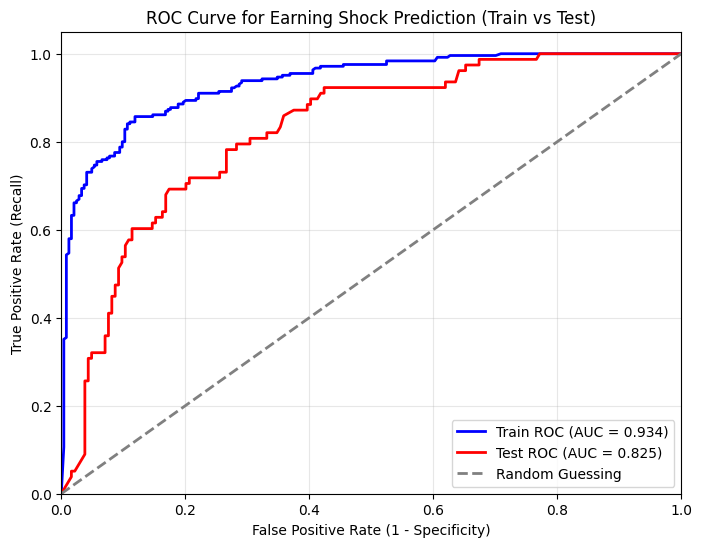

In [191]:
# 함수 실행 (앞서 구한 train_auc, test_auc 변수를 그대로 전달)
plot_roc_curve(xgb_model_all, X_train_final, y_train, X_test_final, y_test, train_auc, test_auc)

# 팩터 모형

## 데이터 만들기

### 개별 주가수익률 가져오기

In [192]:
file_path3 = {
  'car_return' : '/content/quarterly_returns_car.csv',
  'semi_return' : '/content/quarterly_returns_semi.csv',
  'ship_return' : '/content/quarterly_returns_ship.csv',
}

In [193]:
car_return = pd.read_csv(file_path3['car_return'])
semi_return = pd.read_csv(file_path3['semi_return'])
ship_return = pd.read_csv(file_path3['ship_return'])

In [194]:
return_df = pd.concat([car_return,semi_return,ship_return])
returns = {
    'car' : car_return,
    'semi' : semi_return,
    'ship' : ship_return
}

### 3팩터 모형을 만들기 위한 데이터 전처리

In [195]:
import pandas as pd
import yfinance as yf

# Function to load and preprocess each DataFrame
def load_and_preprocess_df(filename, prefix):
    # Load the Excel file without a header
    df = pd.read_excel(filename, header=None)

    # Dynamically find the header row by searching for '일자'
    header_row_idx = None
    for i in range(min(10, len(df))):
        if df.iloc[i].astype(str).str.contains('일자').any():
            header_row_idx = i
            break

    if header_row_idx is None:
        raise KeyError(f"Could not find '일자' in the first 10 rows of {filename}")

    # Set the identified row as header
    new_columns = df.iloc[header_row_idx].astype(str).str.strip()
    df = df[header_row_idx + 1:].copy()
    df.columns = new_columns

    # Mapping for the factor levels
    col_mapping = {
        'HIGH': f'{prefix}-High',
        'UPPER-MIDDLE': f'{prefix}-UM',
        'MEDIUM': f'{prefix}-Medium',
        'LOW-MIDDLE': f'{prefix}-LM',
        'LOW': f'{prefix}-Low'
    }

    # Rename using the mapping
    df = df.rename(columns=col_mapping)

    # Convert '일자' to datetime and handle potential formatting issues
    if '일자' in df.columns:
        # Some Excel files use dots as separators (e.g., 2021.05.27)
        df['일자'] = pd.to_datetime(df['일자'].astype(str).str.replace('.', '-'))
        df.set_index('일자', inplace=True)
    else:
        raise KeyError(f"'일자' column not found in {filename} even after dynamic search.")

    # Ensure data is numeric
    return df.apply(pd.to_numeric, errors='coerce')

In [196]:
import pandas as pd
import yfinance as yf

# ==========================================
# Step 1. 시장 수익률(Rm) 구하기: KOSPI 지수 활용 (분기별 변환)
# ==========================================
kospi = yf.download('^KS11', start='2000-01-04', end='2026-05-28')

# 코스피 '종가(Close)'를 분기 말(Quarter End) 기준으로 리샘플링
kospi_quarterly = kospi['Close'].resample('QE').last()

df_market = pd.DataFrame(index=kospi_quarterly.index)
# 일별 수익률이 아닌, 분기별 수익률로 계산
df_market['Rm'] = kospi_quarterly.pct_change()

# ==========================================
# Step 2. 실제 CD 91일물 데이터로 분기별 무위험 수익률(Rf) 세팅하기
# ==========================================
df_cd91 = pd.read_csv('/content/cd91_quaterly.csv')

# '2024/Q1' 포맷의 슬래시(/)를 제거하고 분기 말 날짜 Timestamp로 변환하여 KOSPI와 인덱스를 맞춤
df_cd91['Date'] = df_cd91['Date'].str.replace('/', '')
df_cd91['Date'] = pd.PeriodIndex(df_cd91['Date'], freq='Q').to_timestamp(how='end').normalize()
df_cd91.set_index('Date', inplace=True)

# KOSPI 분기 인덱스와 CD91 분기 인덱스를 병합 (완벽한 1:1 매칭)
df_market = df_market.join(df_cd91['CD91'], how='inner')

# 연 이자율(%)을 분기별 복리 무위험 수익률로 환산 (1년 = 4분기)
df_market['Rf'] = (1 + df_market['CD91'] / 100) ** (1/4) - 1

# ==========================================
# Step 3. 최종 시장 팩터 (Rm - Rf) 계산
# ==========================================
# 코스피 분기별 수익률에서 분기별 무위험 수익률을 뺍니다.
df_market['Mkt_RF'] = df_market['Rm'] - df_market['Rf']

# 결측치 제거
df_market = df_market.dropna(subset=['Rm', 'Mkt_RF'])

print("📊 Quarterly Market Factor (Mkt_RF) Calculation Complete!")
print(df_market[['Rm', 'CD91', 'Rf', 'Mkt_RF']].head())


########### SMB, HML 팩터 분기 별로 구하기
# 1. Load and preprocess all files
df_small = load_and_preprocess_df('FactorModel_Size&BookValue(5X5)_소형.xlsx', '소형')
df_sm_mid = load_and_preprocess_df('FactorModel_Size&BookValue(5X5)_중소형.xlsx', '중소형')
df_mid = load_and_preprocess_df('FactorModel_Size&BookValue(5X5)_중형.xlsx', '중형')
df_mid_big = load_and_preprocess_df('FactorModel_Size&BookValue(5X5)_중대형.xlsx', '중대형')
df_big = load_and_preprocess_df('FactorModel_Size&BookValue(5X5)_대형.xlsx', '대형')

# 2. Merge dataframes
dfs = [df_small, df_sm_mid, df_mid, df_mid_big, df_big]
df_25port = pd.concat(dfs, axis=1)

# ==========================================
# 3. [FIX] Calculate QUARTERLY returns directly
# ==========================================
# 리샘플링을 먼저 진행하여 분기 말 가격을 추출한 뒤 수익률을 계산합니다.
df_25port_quarterly = df_25port.resample('QE').last()
df_25port_returns = df_25port_quarterly.pct_change().dropna()

# 4. Define columns for SMB/HML
small_cols = ['소형-High', '소형-UM', '소형-Medium', '소형-LM', '소형-Low']
big_cols = ['대형-High', '대형-UM', '대형-Medium', '대형-LM', '대형-Low']
high_cols = ['소형-High', '중소형-High', '중형-High', '중대형-High', '대형-High']
low_cols = ['소형-Low', '중소형-Low', '중형-Low', '중대형-Low', '대형-Low']

# 5. Calculate Quarterly Factors
df_factors = pd.DataFrame(index=df_25port_returns.index)
df_factors['SMB'] = df_25port_returns[small_cols].mean(axis=1) - df_25port_returns[big_cols].mean(axis=1)
df_factors['HML'] = df_25port_returns[high_cols].mean(axis=1) - df_25port_returns[low_cols].mean(axis=1)

# ==========================================
# 6. Merge with Quarterly Market Factor (Mkt_RF)
# ==========================================
# 이제 양쪽 데이터프레임 모두 완벽한 분기 말(QE) 인덱스를 가지고 있으므로 inner join이 정상 작동합니다.
ff_3factor_quarterly = pd.merge(df_factors, df_market[['Mkt_RF']], left_index=True, right_index=True, how='inner')

# 인덱스 포맷을 '2021Q2' 형태로 변경하여 가독성 높이기
ff_3factor_quarterly.index = ff_3factor_quarterly.index.to_period('Q')

print("--- 최종 분기별 파마-프렌치 3팩터 (SMB, HML, Mkt_RF) ---")
display(ff_3factor_quarterly.head())

[*********************100%***********************]  1 of 1 completed


📊 Quarterly Market Factor (Mkt_RF) Calculation Complete!
                  Rm    CD91        Rf    Mkt_RF
Date                                            
2014-03-31 -0.012792  0.0265  0.000066 -0.012859
2014-06-30  0.008360  0.0265  0.000066  0.008294
2014-09-30  0.008930  0.0252  0.000063  0.008867
2014-12-31 -0.051730  0.0216  0.000054 -0.051784
2015-03-31  0.065484  0.0206  0.000051  0.065432
--- 최종 분기별 파마-프렌치 3팩터 (SMB, HML, Mkt_RF) ---


,SMB,HML,Mkt_RF
2021Q3,-0.005226,-0.027774,-0.069138
2021Q4,0.022490,-0.037121,-0.029738
2022Q1,0.055344,0.094905,-0.073921
2022Q2,-0.068904,0.067765,-0.154165
2022Q3,-0.008795,0.031411,-0.076012


#### 팩터 데이터와 주가 수익률 데이터 합쳐주기

In [197]:
import pandas as pd

final_ff_dfs = {}
sectors = ['car', 'semi', 'ship']
methods = ['rf_mlp', 'lasso_mlp', 'xgboost']

# 1. 파마프렌치 팩터 데이터 준비 (타입 변환 확인)
ff_factors = ff_3factor_quarterly.copy()
if not isinstance(ff_factors.index, pd.PeriodIndex):
    ff_factors.index = pd.PeriodIndex(ff_factors.index, freq='Q')
ff_factors.index.name = 'period'
ff_factors = ff_factors.reset_index()

for sector in sectors:
    for method in methods:
        # ① 어닝 팩터 데이터 준비
        # earning_results[sector][method]가 period, corp_code를 포함하고 있다고 가정
        df_model = earning_results[sector][method].copy()
        df_model = df_model.rename(columns={'earning_factor': 'Earning_Factor'})

        # 인덱스에 period가 있다면 컬럼으로 빼주기
        if 'period' not in df_model.columns:
            df_model.index.name = 'period'
            df_model = df_model.reset_index()

        # ② 섹터별 수익률 데이터 병합 (중요: returns[sector] 사용)
        # returns[sector]에 'period', 'corp_code', 'Return'이 있는지 확인하세요.
        df_with_returns = pd.merge(
            df_model,
            returns[sector][['period', 'corp_code', 'Return']],
            on=['period', 'corp_code'],
            how='left'
        )

        # ③ Period 타입 통일
        df_with_returns['period'] = pd.PeriodIndex(df_with_returns['period'], freq='Q')

        # ④ 파마프렌치 팩터(Mkt-RF, SMB, HML 등) 병합
        df_final = pd.merge(df_with_returns, ff_factors, on='period', how='left')

        # ⑤ 저장
        dict_key = f"{sector}_{method}"
        final_ff_dfs[dict_key] = df_final

print("✅ 9개의 데이터셋 결합 완료!")
print("생성된 데이터셋 목록:", list(final_ff_dfs.keys()))

# 결과 확인
if 'car_rf_mlp' in final_ff_dfs:
    print("\n[Preview: 자동차 섹터 - RF_MLP 데이터프레임]")
    display(final_ff_dfs['car_rf_mlp'].head())

✅ 9개의 데이터셋 결합 완료!
생성된 데이터셋 목록: ['car_rf_mlp', 'car_lasso_mlp', 'car_xgboost', 'semi_rf_mlp', 'semi_lasso_mlp', 'semi_xgboost', 'ship_rf_mlp', 'ship_lasso_mlp', 'ship_xgboost']

[Preview: 자동차 섹터 - RF_MLP 데이터프레임]


,period,corp_code,Earning_Factor,Return,SMB,HML,Mkt_RF
0,2023Q1,101220,0.209037,0.961071,0.081192,0.006061,0.107430
1,2023Q2,101220,0.207894,0.074442,0.040912,0.006513,0.035204
2,2023Q3,101220,0.220167,-0.174365,-0.063876,0.014155,-0.038783
3,2023Q4,101220,0.212468,-0.041958,-0.053543,0.030797,0.077066
4,2024Q1,101220,0.217858,-0.138686,-0.062001,0.026898,0.034311


## 회귀(파마프랜치 + 어닝쇼크팩터)

#### 어닝 팩터(쇼크 확률)을 10분위수로 나눈 포트폴리오에 대한 파마프렌치

In [225]:
import pandas as pd
import statsmodels.api as sm

# ---------------------------------------------------------
# [사전 준비] final_ff_dfs: 9개의 결합 데이터프레임 딕셔너리
# ---------------------------------------------------------
sectors = ['car', 'semi', 'ship']
methods = ['rf_mlp', 'lasso_mlp', 'xgboost']

print("🔥 9개 케이스 전체 포트폴리오(10분위) OLS 상세 분석을 시작합니다...\n")

for sector in sectors:
    for method in methods:
        dict_key = f"{sector}_{method}"

        # 딕셔너리에 해당 키가 없으면 건너뜀
        if dict_key not in final_ff_dfs:
            print(f"⚠️ {dict_key} 데이터가 없어 건너뜁니다.")
            continue

        model_df = final_ff_dfs[dict_key].copy()

        # 1. 결측치 제거
        cols = ['period', 'Return', 'Mkt_RF', 'SMB', 'HML', 'Earning_Factor']
        model_df = model_df.dropna(subset=cols)

        try:
            # ==========================================
            # 2. 분기별 어닝 팩터 기준 10분위수(Decile) 할당
            # ==========================================
            # rank(method='first')를 사용하여 확률값이 겹쳐도 강제로 10등분하도록 처리
            # 1분위(D1): 가장 낮음(저위험) ~ 10분위(D10): 가장 높음(고위험)
            model_df['Decile'] = model_df.groupby('period')['Earning_Factor'].transform(
                lambda x: pd.qcut(x.rank(method='first'), q=10, labels=False) + 1
            )

            agg_cols = ['Return', 'Mkt_RF', 'SMB', 'HML', 'Earning_Factor']

            print(f"\n================================================================================")
            print(f"🚀 [{sector} 섹터 & {method}] 10분위 포트폴리오 분석 시작")
            print(f"================================================================================")

            # ==========================================
            # 3. 1분위(D1)부터 10분위(D10)까지 순회하며 OLS 실행
            # ==========================================
            for decile in range(1, 11):
                decile_df = model_df[model_df['Decile'] == decile]

                # 해당 분위수에 데이터가 없으면 건너뜀
                if decile_df.empty:
                    print(f"⚠️ D{decile} 포트폴리오: 데이터가 없어 OLS를 건너뜁니다.")
                    continue

                # 기간(period)별로 묶어서 포트폴리오 평균 수익률 및 팩터값 계산
                port_decile = decile_df.groupby('period')[agg_cols].mean().reset_index()

                X = sm.add_constant(port_decile[['Mkt_RF', 'SMB', 'HML', 'Earning_Factor']])
                Y = port_decile['Return']

                try:
                    model_d = sm.OLS(Y, X).fit()

                    # 4. 상세 결과 출력 (summary)
                    risk_label = "초저위험" if decile == 1 else ("초고위험" if decile == 10 else f"위험수준 {decile}/10")
                    print(f"📊 === 분위수 {decile} (D{decile}, {risk_label}) OLS 결과 === 📊")
                    print(model_d.summary())
                    print("\n" + "-"*60 + "\n")

                except Exception as inner_e:
                    # 표본(분기) 수가 부족하여 회귀분석이 깨질 경우 에러 출력 후 다음 분위수로 진행
                    print(f"❌ 분위수 {decile} (D{decile}) 회귀분석 실패: {inner_e}\n")
                    print("-" * 60 + "\n")

        except Exception as e:
            print(f"❌ {dict_key} 전체 분석 중 에러 발생: {e}")
            print("\n" + "="*80 + "\n")

🔥 9개 케이스 전체 포트폴리오(10분위) OLS 상세 분석을 시작합니다...


🚀 [car 섹터 & rf_mlp] 10분위 포트폴리오 분석 시작
📊 === 분위수 1 (D1, 초저위험) OLS 결과 === 📊
                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     7.097
Date:                Fri, 29 May 2026   Prob (F-statistic):             0.0131
Time:                        03:00:23   Log-Likelihood:                 21.386
No. Observations:                  12   AIC:                            -32.77
Df Residuals:                       7   BIC:                            -30.35
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
--------

In [200]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X는 상수항(const)이 포함된 독립변수 데이터프레임이어야 합니다.
vif_data = pd.DataFrame()
vif_data["Feature"] = X_l.columns
vif_data["VIF"] = [variance_inflation_factor(X_l.values, i) for i in range(len(X_l.columns))]

print(vif_data.round(2))

          Feature     VIF
0           const  165.64
1          Mkt_RF    1.38
2             SMB    2.46
3             HML    1.08
4  Earning_Factor    1.88


##### 해석

데이터의 크기와 통계적 유의성이라는 뼈아픈 한계에도 불구하고, 이 실험 결과는 향후 연구를 위한 강력한 힌트를 제공하고 있습니다.

위험군(상/하위 50%)에 따른 어닝 팩터의 명확한 '비대칭성'통계적 유의성을 차치하고 회귀 계수(coef)의 방향성만 보았을 때, 고위험군과 저위험군 사이에서 어닝 팩터가 반대로 작동하는 징후가 포착되었습니다. 자동차 섹터 (RF_MLP): 상위 50%(고위험)에서는 어닝 팩터 계수가 -0.6291 인 반면, 하위 50%(저위험)에서는 +0.6229 로 나타났습니다.  이는 어닝 쇼크 확률이라는 동일한 변수가 우량주(안전망이 있는 저위험군)와 부실주(여력이 없는 고위험군)에 미치는 영향이 본질적으로 다름을 시사합니다. 제안서에서 주장한 "다양한 요인이 복합적이고 비선형적으로 작용한다"는 가설을 뒷받침하는 강력한 정황 증거입니다.

#### 패널 회귀를 이용한 파마프렌치

In [202]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# ---------------------------------------------------------
# [사전 준비] final_ff_dfs: 9개의 결합 데이터프레임 딕셔너리
# ---------------------------------------------------------
sectors = ['car', 'semi', 'ship']
methods = ['rf_mlp', 'lasso_mlp', 'xgboost']

print("🔥 9개 케이스 전체 패널 고정효과(Fixed Effects) 모형 상세 분석을 시작합니다...\n")

for sector in sectors:
    for method in methods:
        dict_key = f"{sector}_{method}"

        # 딕셔너리에 해당 키가 없으면 건너뜐
        if dict_key not in final_ff_dfs:
            print(f"⚠️ {dict_key} 데이터가 없어 건너뜁니다.")
            continue

        model_df = final_ff_dfs[dict_key].copy()

        # 1. 결측치 제거
        cols = ['corp_code', 'period', 'Return', 'Mkt_RF', 'SMB', 'HML', 'Earning_Factor']
        model_df = model_df.dropna(subset=cols)

        try:
            # 2. Period 타입을 datetime(Timestamp)으로 변환
            # linearmodels는 PeriodIndex를 시간 인덱스로 인식하지 못하므로 변환이 필수입니다.
            if isinstance(model_df['period'].dtype, pd.PeriodDtype):
                model_df['period'] = model_df['period'].dt.to_timestamp()
            else:
                model_df['period'] = pd.PeriodIndex(model_df['period'], freq='Q').to_timestamp()

            # 3. 패널 데이터 구조를 인식시키기 위한 MultiIndex 설정
            # 기업(Entity)과 시간(Time)을 인덱스로 만듭니다.
            model_df = model_df.set_index(['corp_code', 'period'])

            # 4. 독립변수(X)와 종속변수(Y) 설정
            Y = model_df['Return']
            X = model_df[['Mkt_RF', 'SMB', 'HML', 'Earning_Factor']]
            X = sm.add_constant(X)

            # 5. 개체 고정효과(Entity Effects) 모형 적합
            model_fe = PanelOLS(Y, X, entity_effects=True).fit()

            # 6. 상세 결과 출력 (summary)
            print(f"🔵 === [{sector} 섹터 & {method}] 패널 고정효과 모형 결과 === 🔵")
            print(model_fe.summary)

            # 다음 케이스와 구분하기 위한 큰 선
            print("\n" + "="*80 + "\n")

        except Exception as e:
            print(f"❌ {dict_key} 분석 중 에러 발생: {e}")
            print("\n" + "="*80 + "\n")

🔥 9개 케이스 전체 패널 고정효과(Fixed Effects) 모형 상세 분석을 시작합니다...

🔵 === [car 섹터 & rf_mlp] 패널 고정효과 모형 결과 === 🔵
                          PanelOLS Estimation Summary                           
Dep. Variable:                 Return   R-squared:                        0.0942
Estimator:                   PanelOLS   R-squared (Between):              0.0384
No. Observations:                1504   R-squared (Within):               0.0942
Date:                Fri, May 29 2026   R-squared (Overall):              0.0913
Time:                        02:37:44   Log-likelihood                   -12.569
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      35.549
Entities:                         132   P-value                           0.0000
Avg Obs:                       11.394   Distribution:                  F(4,1368)
Min Obs:                       1.0000                                           
Max Obs:  

In [203]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# X는 상수항(const)이 포함된 독립변수 데이터프레임이어야 합니다.
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.round(2))

          Feature   VIF
0           const  6.73
1          Mkt_RF  1.39
2             SMB  1.49
3             HML  1.07
4  Earning_Factor  1.02


##### 해석

① 섹터별 특화 팩터로서의 가능성 (특히 조선 섹터)
조선(Ship) 섹터에서 RF_MLP 기반 어닝 팩터가 보여준 P-value 0.0049(1% 유의수준)와 계수 값(1.0536)은 매우 인상적입니다.  조선업처럼 수주 기반의 장기 프로젝트가 많은 산업은 재무지표의 비선형적 결합이 주가 수익률에 미치는 영향이 타 산업보다 훨씬 강력할 수 있음을 정량적으로 보여줍니다.  

② 전통 팩터(SMB, HML)의 유의성 확보
이전 소표본 OLS에서는 파마-프렌치 기본 변수들조차 갈팡질팡했으나, 패널 모형에서는 특히 반도체와 조선 섹터에서 시장(Mkt), 규모(SMB), 가치(HML) 변수들이 높은 유의성을 보입니다. 이는 구축된 패널 데이터셋 자체는 신뢰할 수 있는 수준이며, 여기에 추가된 '어닝 팩터'가 전통적 요인들이 설명하지 못하는 추가적인 알파(Alpha)를 포착하려 시도하고 있음을 증명합니다.   
패널 회귀에서 Earning_Factor가 특정 모델(RF)과 특정 섹터(조선, 자동차)에서만 유의하게 나왔다는 사실은, "어닝 쇼크 리스크가 모든 산업에 동일하게 적용되지 않는다"는 실무적인 통찰

③ '어닝 쇼크'의 위험 프리미엄 확인
유의미한 결과가 나온 케이스들에서 어닝 팩터의 계수가 양(+)수라는 점은, MLP가 예측한 어닝 쇼크 확률이 높을수록(실제로는 실적 악화 위험이 클수록) 시장이 이에 대해 더 높은 기대 수익률(위험 프리미엄)을 요구하거나, 혹은 예측 모델이 시장의 과도한 공포를 역으로 포착하고 있을 가능성을 열어둡니다.   

결론적으로: 현재의 패널 회귀는 "절반의 성공"입니다. 데이터 확보로 통계적 기초는 다졌으나, 이제는 모델의 일관성(Robustness)을 확보하고 시간적 통제를 가하는 정교한 튜닝이 필요한 시점입니다.

# 한계

① 회귀 분석에 사용된 Return이 어닝 팩터 산출 시점 이후의 수익률일 가능성이 있다. 만약 실적 발표 시즌의 수익률과 해당 분기 어닝 팩터를 동시에 돌렸다면, 이는 '예측'이 아니라 '동행' 확인에 불과.

# 어닝팩터만을 이용한 단순선형회귀(종속변수는 분기별 개별 주가 수익률)

In [218]:
def run_corporate_ols(sector_key):
    model_df = final_ff_dfs[sector_key].copy()
    model_df = model_df.dropna(subset=['Return', 'Earning_Factor'])

    results = []
    for corp, group in model_df.groupby('corp_code'):
        if len(group) > 5:
            X = sm.add_constant(group[['Earning_Factor']])
            Y = group['Return']
            try:
                model = sm.OLS(Y, X).fit()
                results.append({
                    'corp_code': corp,
                    'beta_EF': model.params['Earning_Factor'],
                    'p_value_EF': model.pvalues['Earning_Factor'],
                    'R2': model.rsquared,
                    'obs': int(model.nobs),
                    'summary': model.summary()
                })
            except: continue
    return pd.DataFrame(results)

In [220]:
# Car (XGBoost) 분석
car_corp_summary = run_corporate_ols('car_xgboost')
print("\n=== [반도체 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===")
display(car_corp_summary.sort_values('p_value_EF').head(10))

# Semiconductor (XGBoost) 분석
semi_corp_summary = run_corporate_ols('semi_xgboost')
print("\n=== [반도체 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===")
display(semi_corp_summary.sort_values('p_value_EF').head(10))

# Shipbuilding (XGBoost) 분석
ship_corp_summary = run_corporate_ols('ship_xgboost')
print("\n=== [조선 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===")
display(ship_corp_summary.sort_values('p_value_EF').head(10))


=== [반도체 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===


,corp_code,beta_EF,p_value_EF,R2,obs,summary
10,112165,43.224358,0.000004,0.890391,12,OLS Regression Res...
22,125576,4.297126,0.030292,0.463237,10,OLS Regression Res...
14,116949,5.172270,0.031335,0.385008,12,OLS Regression Res...
124,1336443,5.034751,0.038458,0.394678,11,OLS Regression Res...
100,495633,-14.969593,0.045900,0.671681,6,OLS Regression Res...
62,164788,0.130985,0.053623,0.000000,12,OLS Regression Res...
56,160047,-7.205523,0.056331,0.317662,12,OLS Regression Res...
77,259545,-2.639900,0.056475,0.317360,12,OLS Regression Res...
82,300405,-20.457592,0.058587,0.312980,12,OLS Regression Res...
122,1084294,-8.256215,0.061429,0.307299,12,OLS Regression Res...



=== [반도체 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===


,corp_code,beta_EF,p_value_EF,R2,obs,summary
108,1383229,-1.234451,0.004783,0.823126,7,OLS Regression Res...
107,1367586,0.422306,0.005209,0.695344,9,OLS Regression Res...
33,411048,36.915330,0.015208,0.460835,12,OLS Regression Res...
93,1037542,-1.483093,0.020778,0.507574,10,OLS Regression Res...
103,1301623,1.098156,0.021382,0.426105,12,OLS Regression Res...
5,137289,-0.684333,0.023440,0.416427,12,OLS Regression Res...
34,411446,-0.751861,0.024514,0.411663,12,OLS Regression Res...
85,920379,-1.449264,0.025904,0.405759,12,OLS Regression Res...
6,158219,-0.739532,0.037336,0.365422,12,OLS Regression Res...
23,298340,3.893231,0.045484,0.342802,12,OLS Regression Res...



=== [조선 섹터: XGBoost] 기업별 OLS 요약 (Top 5) ===


,corp_code,beta_EF,p_value_EF,R2,obs,summary
10,356839,-1.245244,0.031984,0.382740,12,OLS Regression Res...
2,126478,-0.231573,0.195800,0.161192,12,OLS Regression Res...
12,406046,-1.399896,0.200273,0.158278,12,OLS Regression Res...
19,1390344,-0.520363,0.217716,0.147517,12,OLS Regression Res...
4,159795,0.465594,0.252328,0.128606,12,OLS Regression Res...
1,111704,0.735458,0.271149,0.119460,12,OLS Regression Res...
18,1205709,-1.424912,0.306436,0.104075,12,OLS Regression Res...
17,618410,2.910269,0.322519,0.097723,12,OLS Regression Res...
20,1396676,-1.080780,0.335980,0.092687,12,OLS Regression Res...
15,482426,-0.604481,0.346327,0.088978,12,OLS Regression Res...


In [224]:
# 특정 업종 내의 특정 종목에 대해서만 예시 삼아 관찰(다른 업종, 종목들도 모두 확인 가능, 업종 별 corp_summary 변수와 corp_code를 바꿔가면서. corp_code는 json파일에 있는 거 아무거나 보면 됨)
target_summary = semi_corp_summary.loc[semi_corp_summary['corp_code'] == 118275, 'summary'].values[0]
print(target_summary)

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     2.665
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.134
Time:                        02:52:46   Log-Likelihood:                -5.6144
No. Observations:                  12   AIC:                             15.23
Df Residuals:                      10   BIC:                             16.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1415      0.245     -0.

# 포트폴리오 운용에 적용

In [263]:
def decile_portfolio_stats(df):
    port = (
        df.groupby(['period', 'Decile'])['Return']
        .mean()
        .unstack('Decile')
        .sort_index()
    )
    summary = pd.DataFrame({
        'cum_return': (1 + port).prod() - 1,
        'mean_return': port.mean(),
        'volatility': port.std(),
        'sharpe_ann': port.mean() / port.std() * np.sqrt(4),
        'n_periods': port.count(),
    })
    summary.index.name = 'Decile'
    return summary, port


def decile_membership(df):
    return {
        period: {int(decile): sub['corp_code'].tolist()
                 for decile, sub in g.groupby('Decile')}
        for period, g in df.groupby('period')
    }


def plot_decile_cumulative(port_ts, title):
    import matplotlib.pyplot as plt
    cum = (1 + port_ts).cumprod()
    ax = cum.plot(figsize=(10, 6), colormap='RdYlGn_r')
    ax.set_title(f"{title} — Decile Cumulative Return (quaterly rebalanced)")
    ax.set_xlabel('period')
    ax.set_ylabel('Cumulative Growth Multiple (Start = 1)')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
    ax.legend(title='Decile', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return ax


def decile_transition_returns(df):
    d = df.sort_values(['corp_code', 'period']).copy()
    d['prev_Decile'] = d.groupby('corp_code')['Decile'].shift(1)
    d['next_Return'] = d.groupby('corp_code')['Return'].shift(-1)
    d = d.dropna(subset=['prev_Decile', 'next_Return'])
    d['decile_change'] = (d['Decile'] - d['prev_Decile']).astype(int)

    by_change = d.groupby('decile_change')['next_Return'].agg(['mean', 'median', 'std', 'count'])
    matrix = d.pivot_table(
        index='prev_Decile', columns='Decile', values='next_Return', aggfunc='mean'
    )
    return by_change, matrix


=== car_rf_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           1.4802       0.0827      0.0956      1.7288         12
2           0.3960       0.0350      0.1250      0.5594         12
3           0.1281       0.0147      0.1021      0.2871         12
4           0.1876       0.0214      0.1257      0.3401         12
5           0.1741       0.0174      0.0938      0.3710         12
6          -0.0914      -0.0049      0.0818     -0.1205         12
7           0.4890       0.0398      0.1170      0.6813         12
8           0.0100       0.0070      0.1148      0.1219         12
9          -0.1425      -0.0081      0.1017     -0.1584         12
10         -0.1031      -0.0043      0.1032     -0.0836         12

--- car_rf_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-6          

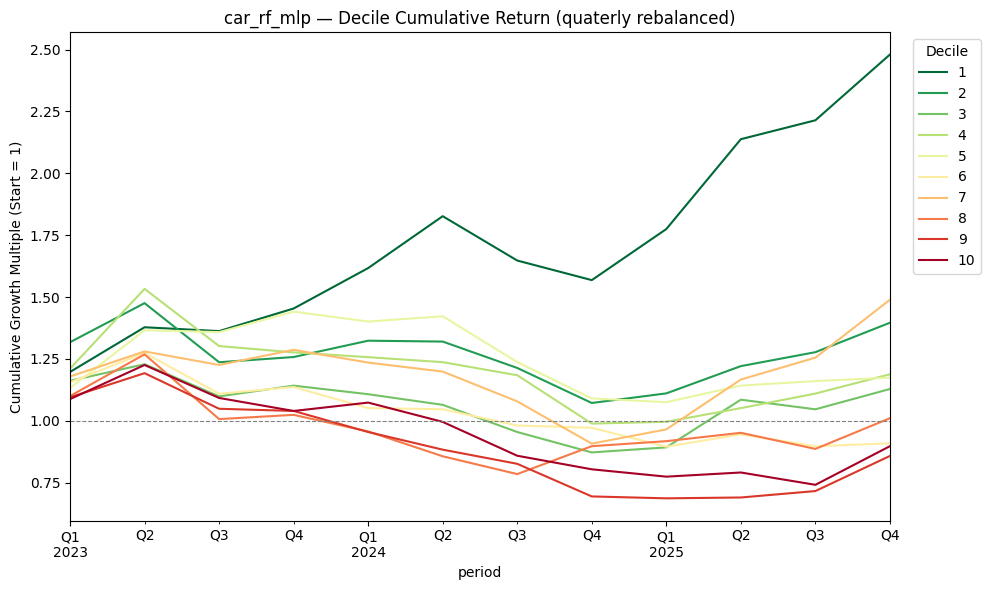


=== car_lasso_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           1.3756       0.0801      0.1118      1.4319         12
2           0.6035       0.0463      0.1203      0.7687         12
3          -0.0410       0.0004      0.0924      0.0078         12
4           0.0027       0.0058      0.1120      0.1039         12
5           0.4267       0.0363      0.1233      0.5888         12
6          -0.0667      -0.0008      0.1029     -0.0161         12
7           0.0427       0.0102      0.1225      0.1670         12
8           0.6115       0.0475      0.1269      0.7477         12
9          -0.2978      -0.0227      0.1150     -0.3954         12
10         -0.0826      -0.0028      0.1009     -0.0548         12

--- car_lasso_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-9    

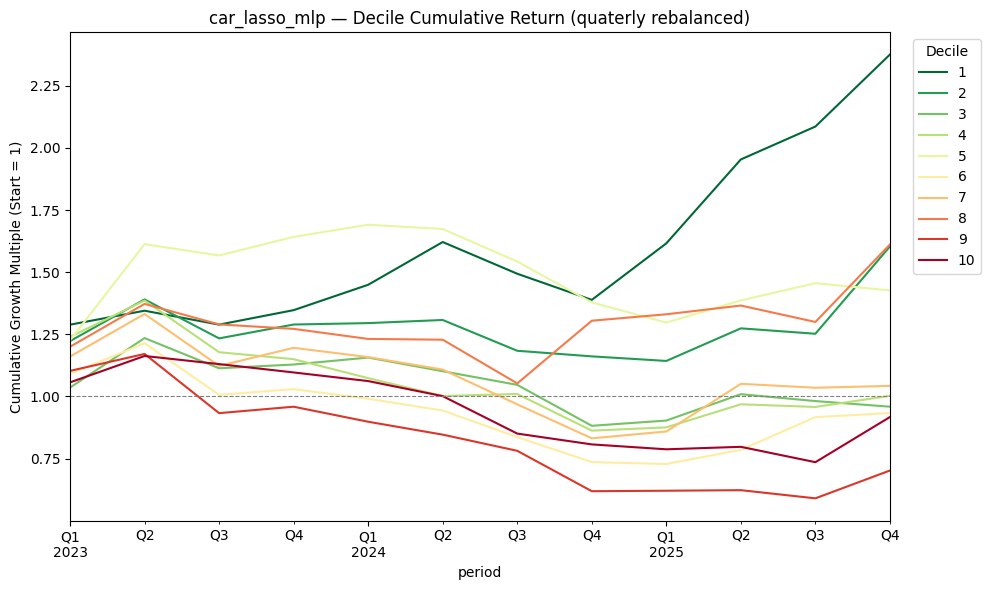


=== car_xgboost Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           0.8140       0.0564      0.1112      1.0152         12
2           0.4437       0.0350      0.0973      0.7203         12
3           0.3887       0.0360      0.1385      0.5203         12
4           0.4174       0.0400      0.1570      0.5092         12
5           0.2175       0.0218      0.1058      0.4112         12
6           0.3856       0.0335      0.1160      0.5777         12
7           0.3539       0.0308      0.1079      0.5702         12
8          -0.2238      -0.0149      0.1156     -0.2573         12
9          -0.0803      -0.0056      0.0526     -0.2147         12
10         -0.3366      -0.0275      0.1169     -0.4701         12

--- car_xgboost Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-7        

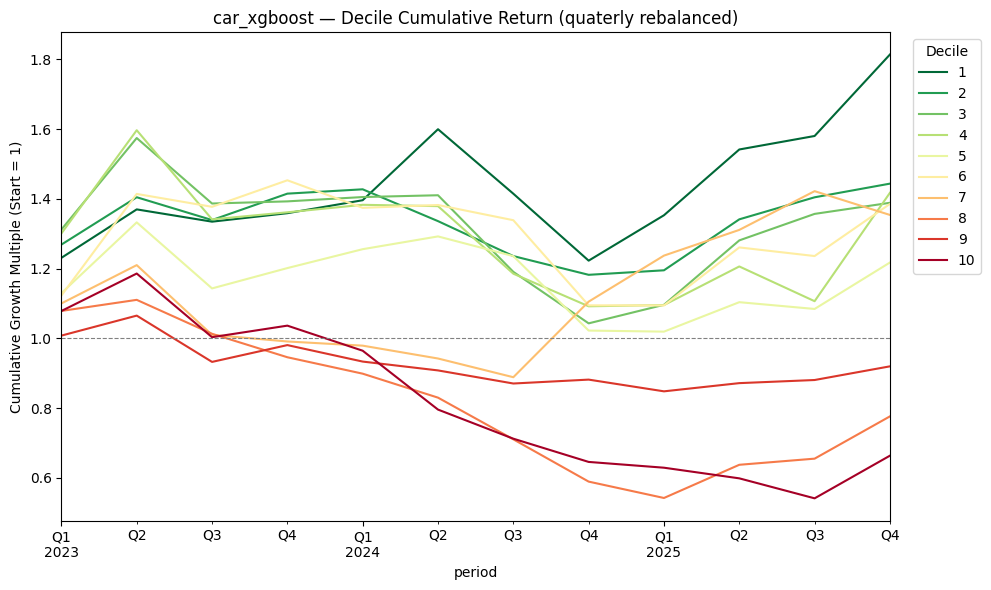


=== semi_rf_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           1.7418       0.0987      0.1558      1.2671         12
2           2.1882       0.1207      0.2044      1.1815         12
3           1.0391       0.0824      0.2302      0.7155         12
4           1.0616       0.0785      0.1904      0.8248         12
5           1.0231       0.0764      0.1902      0.8030         12
6           0.6476       0.0591      0.1938      0.6102         12
7           0.6135       0.0533      0.1649      0.6463         12
8           0.9574       0.0670      0.1471      0.9118         12
9           0.3708       0.0405      0.1822      0.4448         12
10          0.2884       0.0422      0.2234      0.3775         12

--- semi_rf_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-7        

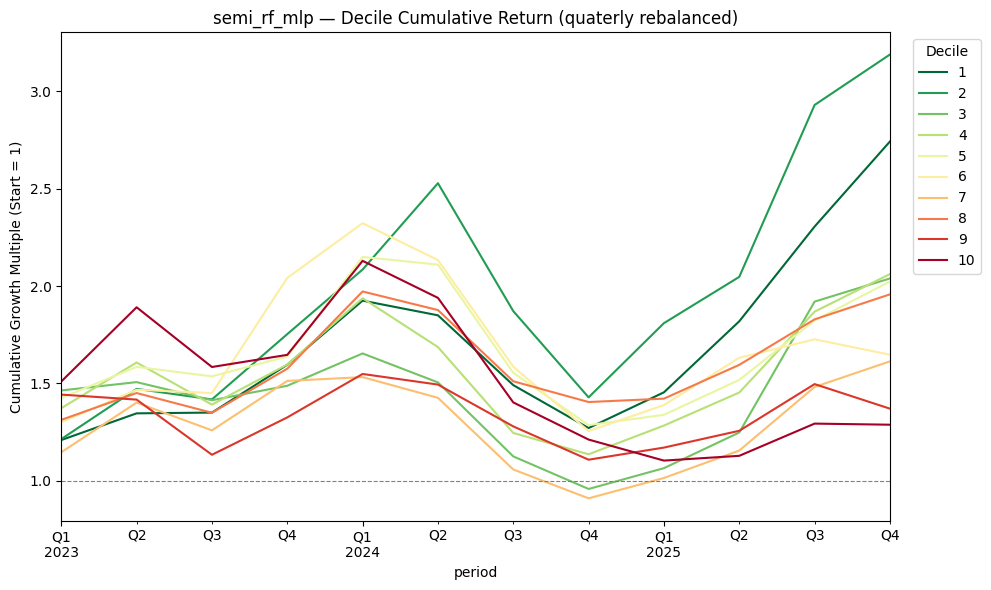


=== semi_lasso_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           1.2355       0.0774      0.1363      1.1355         12
2           0.9630       0.0718      0.1747      0.8214         12
3           1.2088       0.0823      0.1764      0.9333         12
4           2.0810       0.1183      0.2179      1.0859         12
5           1.3478       0.0901      0.1938      0.9301         12
6           0.7403       0.0624      0.1813      0.6888         12
7           2.0003       0.1136      0.1996      1.1386         12
8          -0.0103       0.0131      0.1768      0.1480         12
9           0.2759       0.0359      0.1882      0.3821         12
10          0.4147       0.0513      0.2290      0.4483         12

--- semi_lasso_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-9  

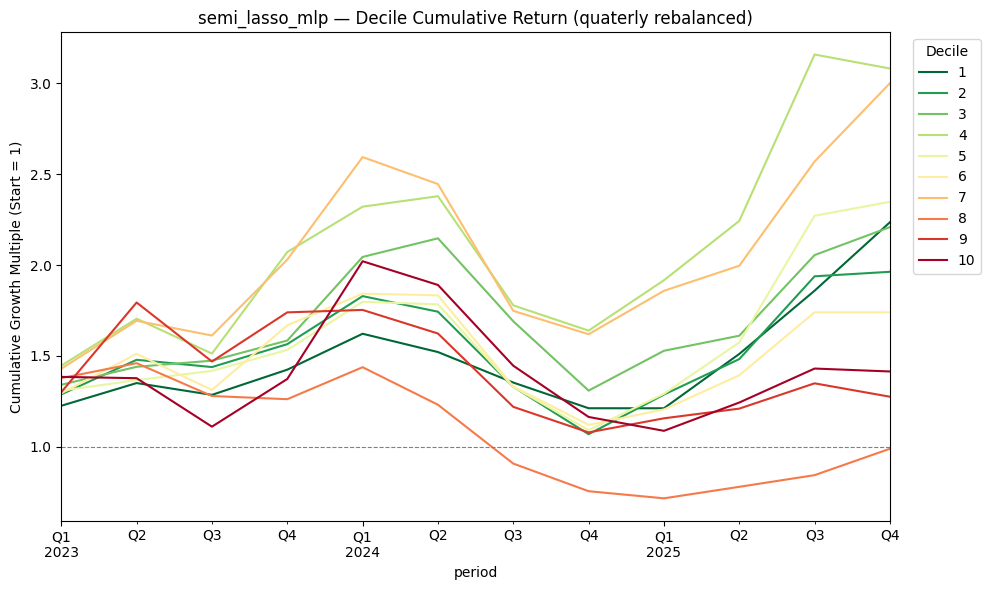


=== semi_xgboost Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           1.2333       0.0804      0.1570      1.0240         12
2           1.7480       0.1078      0.2138      1.0088         12
3           2.5456       0.1368      0.2466      1.1097         12
4           2.2878       0.1174      0.1715      1.3687         12
5           0.9931       0.0745      0.1901      0.7842         12
6           0.1902       0.0279      0.1649      0.3383         12
7           0.3395       0.0352      0.1528      0.4609         12
8           0.3020       0.0410      0.2035      0.4032         12
9           0.5970       0.0482      0.1374      0.7014         12
10          0.3168       0.0448      0.2309      0.3883         12

--- semi_xgboost Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-6      

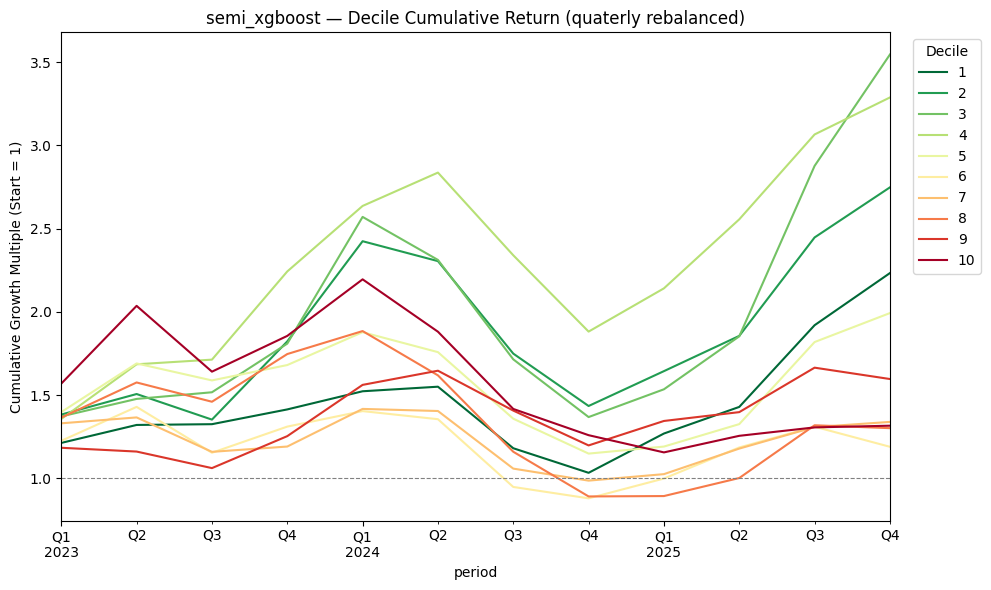


=== ship_rf_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           0.4964       0.0429      0.1505      0.5696         12
2           2.2686       0.1225      0.2321      1.0558         12
3           2.4290       0.1383      0.2839      0.9741         12
4           1.8712       0.1310      0.3264      0.8029         12
5           0.2320       0.0378      0.2257      0.3345         12
6          10.8995       0.3259      0.6958      0.9369         12
7          -0.0989       0.0032      0.1661      0.0386         12
8           1.4879       0.0984      0.2164      0.9091         12
9           0.4461       0.0447      0.1751      0.5112         12
10          1.4906       0.1094      0.2784      0.7860         12

--- ship_rf_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-7        

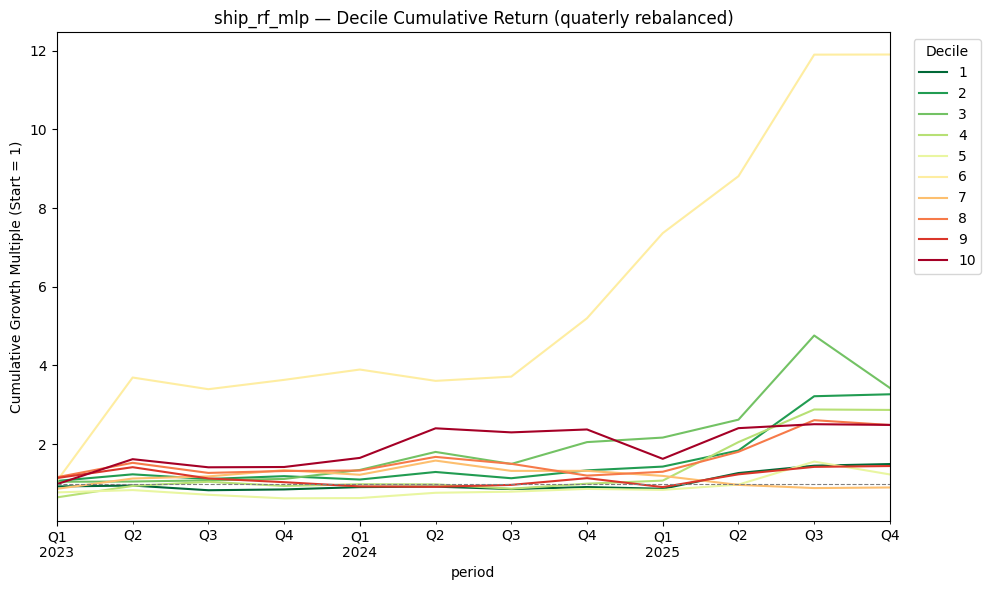


=== ship_lasso_mlp Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           0.8096       0.0608      0.1577      0.7714         12
2           0.1864       0.0381      0.2480      0.3070         12
3           1.5606       0.0919      0.1526      1.2052         12
4           1.7787       0.1190      0.2939      0.8097         12
5           0.3103       0.0372      0.1899      0.3922         12
6           0.8822       0.0726      0.2039      0.7119         12
7           1.2412       0.0806      0.1595      1.0101         12
8           2.8923       0.1438      0.2481      1.1593         12
9           1.8229       0.1001      0.1592      1.2580         12
10          3.1131       0.2177      0.6368      0.6837         12

--- ship_lasso_mlp Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-8  

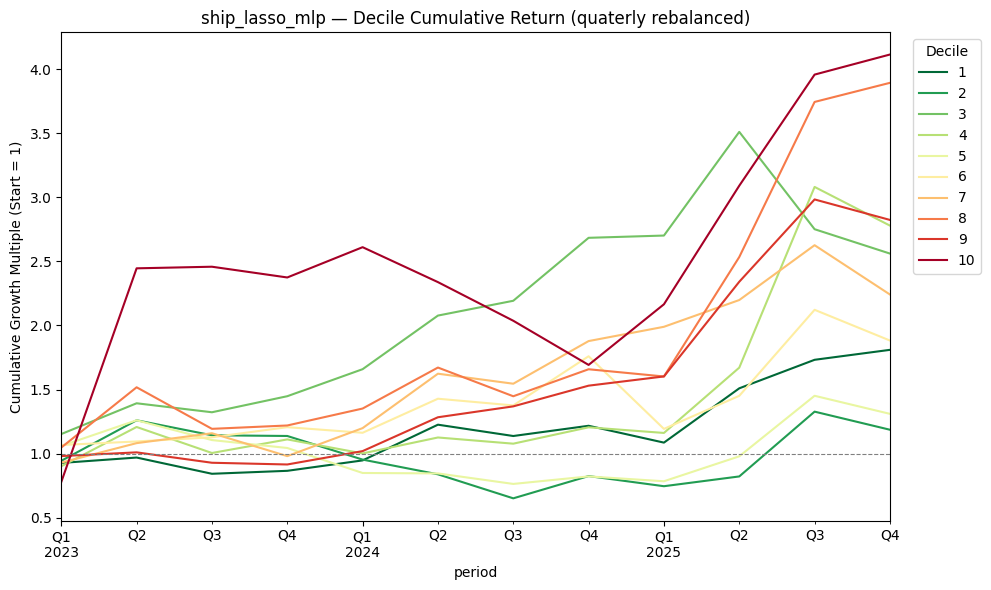


=== ship_xgboost Decile Portfolio ===
        cum_return  mean_return  volatility  sharpe_ann  n_periods
Decile                                                            
1           2.3893       0.1216      0.1964      1.2389         12
2           0.8638       0.0731      0.2220      0.6587         12
3           3.8590       0.1592      0.2297      1.3859         12
4           3.7441       0.1654      0.2708      1.2221         12
5           3.0841       0.1479      0.2532      1.1685         12
6           2.0922       0.1114      0.1816      1.2272         12
7           5.0295       0.1905      0.2974      1.2812         12
8          -0.4628      -0.0390      0.1490     -0.5232         12
9          -0.6867      -0.0817      0.1463     -1.1172         12
10          0.7167       0.1185      0.5446      0.4350         12

--- ship_xgboost Decile per transition Average Return ---
                 mean  median     std  count
decile_change                               
-7      

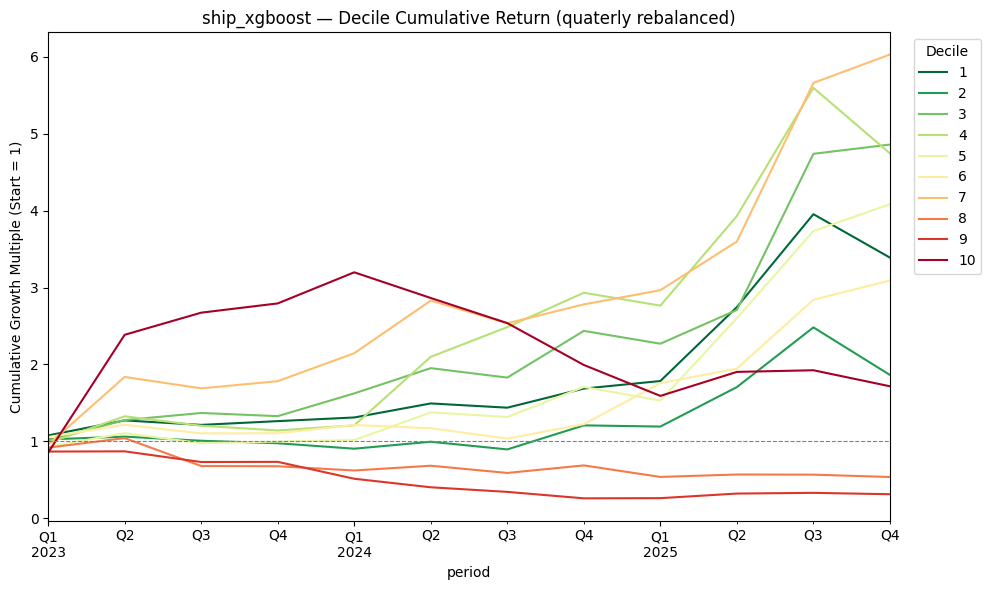

In [264]:
results = {}
sectors = ['car', 'semi', 'ship']
methods = ['rf_mlp', 'lasso_mlp', 'xgboost']
for sector in sectors:
    for method in methods:
        dict_key = f"{sector}_{method}"

        # 딕셔너리에 해당 키가 없으면 건너뜀
        if dict_key not in final_ff_dfs:
            print(f"⚠️ {dict_key} 데이터가 없어 건너뜁니다.")
            continue

        model_df = final_ff_dfs[dict_key].copy()

        # 1. 결측치 제거
        cols = ['period', 'Return', 'Mkt_RF', 'SMB', 'HML', 'Earning_Factor']
        model_df = model_df.dropna(subset=cols)

        # ==========================================
        # 2. 분기별 어닝 팩터 기준 10분위수(Decile) 할당
        # ==========================================
        # rank(method='first')를 사용하여 확률값이 겹쳐도 강제로 10등분하도록 처리
        # 1분위(D1): 가장 낮음(저위험) ~ 10분위(D10): 가장 높음(고위험)
        model_df['Decile'] = model_df.groupby('period')['Earning_Factor'].transform(
            lambda x: pd.qcut(x.rank(method='first'), q=10, labels=False) + 1
        )

        # ==========================================
        # 3. Decile 포트폴리오 수익률 / 변동성
        # ==========================================
        stats, port_ts = decile_portfolio_stats(model_df)
        by_change, trans_matrix = decile_transition_returns(model_df)
        members = decile_membership(model_df)

        results[dict_key] = {
            'stats': stats,
            'port_ts': port_ts,
            'by_change': by_change,
            'matrix': trans_matrix,
            'members': members,
        }

        print(f"\n=== {dict_key} Decile Portfolio ===")
        print(stats.round(4))
        print(f"\n--- {dict_key} Decile per transition Average Return ---")
        print(by_change.round(4))

        plot_decile_cumulative(port_ts, dict_key)

ship_xgboost Decile 전이별 평균 Return의 경우를 보자면,

주어진 기간 내에서, 분위수가 -1만큼 변하는 경우(1분위수가 안정, 10분위수가 위험임. 즉, 분위수가 낮아질수록 어닝쇼크 확률이 낮은 것), 다음 분기까지 주가 수익률이 평균적으로 11.43%을 보인다는 것(주어진 기간 동안 어닝쇼크확률의 분위수가 -1만큼 변한 경우는 42건이고 그 42건의 경우에 대해 평균수익률을 계산했더니 11.43%가 나온 것).

매 분기 리밸런싱 맞음. 지금 구조는 정확히 그렇게 가정:

decile_portfolio_stats가 groupby(['period', 'Decile'])['Return'].mean()을 하니까, period t의 D5 포트폴리오 수익률은 **"period t에 D5로 분류된 종목들의 t분기 수익률 평균"**이야. 전 분기에 누가 D5였는지는 전혀 안 봄.
즉, 각 분기 시작 시점에 새로 분류해서 종목을 다시 사는 분기별 리밸런싱(quarterly rebalance) 동일가중 포트폴리오임. 이게 학계 decile sort의 표준 방식.
거래비용/세금/슬리피지는 무시한 이론적 수익률이고, 회전율(turnover)이 높을수록 실거래에선 성과가 깎임. 회전율은 members dict에서 set(members[t][d]) ^ set(members[t+1][d]) 로 분기마다 얼마나 갈리는지 직접 계산 가능.

=================================================



한편 조선업종의 경우 어닝 쇼크 확률이 낮은 기업들이 오히려 좋은 수익률을 달성. 이는 동일가중이라 소형주 편향이 박혀 있음. 특히 조선업종에서 "고분위 = 고수익" 현상은 operating leverage가 큰 중소형 조선소(또는 한화오션처럼 부실에서 회복된 종목)가 호황에 폭발한 효과일 가능성이 매우 큼. 동일가중은 대형주와 소형주를 같은 비중으로 묶기 때문에 사이클 베타가 큰 소형주가 결과를 지배함. 시가총액가중 버전으로 다시 돌리면 조선 패턴이 약해지거나 뒤집힐 수 있음.





자동차: "저쇼크 = 승자"가 자연스러운 레짐
한국 자동차는 2023-2025년 사이 현대차/기아 중심의 미국·인도 점유율 확장기였고, 환율(원/달러 강세)도 수출주에 우호적이었음.
어닝쇼크확률이 낮은 종목은 거의 정의상 현금흐름이 안정적인 OEM 대형주(현대차, 기아)와 1차 벤더 우량주임. 이런 종목은 펀더멘털 모멘텀이 그대로 주가로 전달됨.
반대로 어닝쇼크확률이 높은 종목은 티어2/티어3 부품사, 전기차 전환에 뒤처진 사업부 의존 중소형주 — 이쪽은 마진 압박과 OEM 단가인하의 직격탄을 받음.
즉, 자동차 산업처럼 밸류체인이 위계적이고 수익성 격차가 구조적인 업종에서는 어닝쇼크확률이 그대로 "구조적 약자"를 라벨링하는 효과가 있고, 호황기엔 강자가 더 강해짐. 이 결과는 "어닝쇼크 팩터의 발견"이라기보단 퀄리티/사이즈 팩터를 다른 이름으로 본 것일 가능성이 크고, 따라서 통제변수로 시총·ROE·부채비율을 넣고 회귀해야 진짜 효과인지 가려짐.

반도체: 같은 메커니즘이 더 극단적
2023-2025는 AI/HBM 자본지출 사이클의 정점기. 삼성전자·SK하이닉스가 HBM 공급망의 거의 모든 마진을 흡수했고, 그 다음 layer(소재·장비 빅네임)까지가 수혜자임.
이 메가캡들은 어닝쇼크확률이 가장 낮은 종목군에 들어감 (현금·점유율·다각화). D1-D3이 이긴 건 사실상 메가캡 dominance와 동의어임.
한국 반도체 유니버스 160개에서 중하위 종목들은 fabless·테스트장비·소재 중소형으로, AI 사이클의 수혜가 균등하지 않게 분배됐고 일부는 오히려 메모리 가격 변동성에 그대로 노출됨. 어닝쇼크확률이 높은 분위에 이런 종목들이 모이면서 underperform.
따라서 반도체 결과 역시 "저쇼크 팩터"라기보다 "메가캡 + AI 테마 노출"의 대체 측정치일 가능성이 매우 큼. 만약 시가총액가중으로 바꾸면 D1 수익률이 더 폭발할 거고(그건 정상), 동시에 다른 분위들 사이의 차이는 흐려질 거임.

조선: 이게 진짜 흥미로운 케이스
한국 조선은 2023-2025년이 신조 슈퍼사이클임. LNG선·메탄올선·이중연료선 신규 발주가 폭증하면서 빅3(HD현대중공업, 삼성중공업, 한화오션)뿐 아니라 중형 조선소까지 수주잔고가 빠르게 채워짐.
사이클 진입 직전(2022 말2023 초) 상황을 보면: 오랜 적자·구조조정·증자 이력으로 어닝쇼크확률 모델은 이 종목들을 당연히 고분위(D8D10)에 배치함. 한화오션(구 대우조선)이 전형적.
그런데 조선업의 핵심 특성은 수주잔고가 1-2년 뒤 매출로 잡히는 lag 구조임. 사이클이 돌면 적자 → 흑자전환이 동시에 일어나면서 EPS가 음수에서 양수로 점프하고, 이는 작은 베이스에서 시작하기 때문에 % 수익률로 가장 큰 종목들이 가장 위험하다고 라벨링됐던 종목들임.
즉 어닝쇼크확률은 사이클 진입 시점에서는 정확하게 "운영 레버리지가 가장 큰 종목"을 식별하는 신호인데, 이게 호황기엔 risk premium이 아니라 cyclical beta로 발현됨. 어닝쇼크확률 ↑ ≈ operating leverage ↑ ≈ 사이클 업사이드 ↑.
조선업이 30개사밖에 안 되고 빅3 + 한화오션 같은 몇 종목이 시총·뉴스플로우를 지배하는 구조이기 때문에, 고분위 분위 = 사실상 한화오션·중형 조선소 ≒ **20232025 슈퍼사이클의 가장 큰 수혜군**으로 자동 매칭됨.

In [259]:
results['car_rf_mlp']['members']

{Period('2023Q1', 'Q-DEC'): {1: [106641,
   111874,
   116949,
   126201,
   133858,
   134316,
   151128,
   155151,
   160047,
   164788,
   225159,
   366137,
   937324],
  2: [101220,
   106623,
   114154,
   125521,
   167192,
   173078,
   174004,
   269852,
   305668,
   573579,
   617998,
   1042775],
  3: [102353,
   117179,
   163114,
   164502,
   173874,
   201742,
   259545,
   264714,
   357935,
   398792,
   659976,
   783246],
  4: [118008,
   134477,
   134510,
   139083,
   153278,
   156354,
   199988,
   498001,
   531865,
   803425,
   1036446,
   1532603],
  5: [111847,
   117726,
   155124,
   155373,
   160010,
   161125,
   166272,
   166315,
   299002,
   556615,
   799177,
   1182578],
  6: [119672,
   132992,
   133663,
   137234,
   142883,
   160418,
   162832,
   447928,
   486370,
   491938,
   578538,
   870481],
  7: [102618,
   110583,
   129642,
   139153,
   140858,
   143226,
   147152,
   152039,
   180795,
   302582,
   646732,
   800145],
  8: [

In [237]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [239]:
d = model_df.sort_values(['corp_code', 'period'])
d['prev_Decile'] = d.groupby('corp_code')['Decile'].shift(1)
d = d.dropna(subset=['prev_Decile'])
d['decile_change'] = (d['Decile'] - d['prev_Decile']).astype(int)

In [240]:
d

,period,corp_code,Earning_Factor,Return,SMB,HML,Mkt_RF,Decile,prev_Decile,decile_change
1,2023Q2,111193,0.320928,0.211556,0.040912,0.006513,0.035204,3,3.0,0
2,2023Q3,111193,0.280131,-0.153846,-0.063876,0.014155,-0.038783,3,3.0,0
3,2023Q4,111193,0.243588,0.065455,-0.053543,0.030797,0.077066,2,3.0,-1
4,2024Q1,111193,0.225038,0.095563,-0.062001,0.026898,0.034311,1,2.0,-1
5,2024Q2,111193,0.217907,0.078660,-0.036264,0.140885,0.018548,1,1.0,0
6,2024Q3,111193,0.217907,-0.129242,-0.013494,0.001642,-0.073198,2,1.0,1
7,2024Q4,111193,0.206654,0.065506,0.011941,0.039374,-0.074809,1,2.0,-1
8,2025Q1,111193,0.206654,0.231128,-0.057046,0.019237,0.033946,1,1.0,0
9,2025Q2,111193,0.206654,0.507585,-0.079351,0.084766,0.237963,1,1.0,0
10,2025Q3,111193,0.206654,0.220126,-0.106250,-0.059091,0.114824,1,1.0,0


In [241]:
by_change = d.groupby('decile_change')['Return'].agg(['mean', 'median', 'std', 'count'])

In [242]:
by_change

,mean,median,std,count
decile_change,,,,
-7,-0.037621,-0.037621,NaN,1
-6,-0.015418,-0.015418,0.101453,2
-5,-0.037705,-0.037705,NaN,1
-4,-0.164557,-0.164557,NaN,1
-3,0.207159,0.121827,0.361120,11
-2,0.238611,0.039302,0.378443,10
-1,0.114261,0.071380,0.320191,42
0,0.119950,0.043011,0.559731,97
1,0.082805,0.072001,0.213242,42


In [243]:
matrix = d.pivot_table(index='prev_Decile', columns='Decile', values='Return', aggfunc='mean')

In [244]:
matrix

Decile,1,2,3,4,5,6,7,8,9,10
prev_Decile,,,,,,,,,,
1.0,0.124224,-0.030994,0.260521,0.254814,NaN,NaN,NaN,-0.072510,NaN,NaN
2.0,0.110254,0.016086,0.155699,-0.078571,-0.009202,0.089663,NaN,NaN,NaN,NaN
3.0,0.276039,0.092968,0.180848,0.176877,0.315971,0.232877,NaN,NaN,NaN,NaN
4.0,0.121827,0.036161,0.205721,0.360556,0.216020,0.214704,-0.267928,0.548578,NaN,-0.073086
5.0,NaN,0.404476,0.030254,0.132141,0.295095,0.101866,NaN,NaN,-0.079727,NaN
6.0,-0.037705,-0.164557,0.198974,NaN,-0.022343,0.044825,0.093243,-0.008524,-0.111814,NaN
7.0,NaN,NaN,NaN,0.136732,-0.075926,0.077945,0.129176,0.054703,-0.303167,0.267425
8.0,-0.037621,NaN,NaN,NaN,NaN,0.796519,0.517619,-0.115619,-0.159990,-0.034010
9.0,NaN,NaN,-0.087156,NaN,NaN,-0.053512,0.256996,-0.103555,-0.061151,-0.085175


## 팩터의 유용성에 대한 통계검정(유의하지 않다. 그러나 딱히 필요는 X)


=== car_rf_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           1.4802       0.0827      0.0956         12
2           0.3960       0.0350      0.1250         12
3           0.1281       0.0147      0.1021         12
4           0.1876       0.0214      0.1257         12
5           0.1741       0.0174      0.0938         12
6          -0.0914      -0.0049      0.0818         12
7           0.4890       0.0398      0.1170         12
8           0.0100       0.0070      0.1148         12
9          -0.1425      -0.0081      0.1017         12
10         -0.1031      -0.0043      0.1032         12

--- car_rf_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-6             0.0394  0.0394  0.2124      2
-5            -0.0855 -0.1929  0.2014      5
-4             0.0181  0.0185  0.1414      9
-3            -0.0417 -0.0296  0.1563    

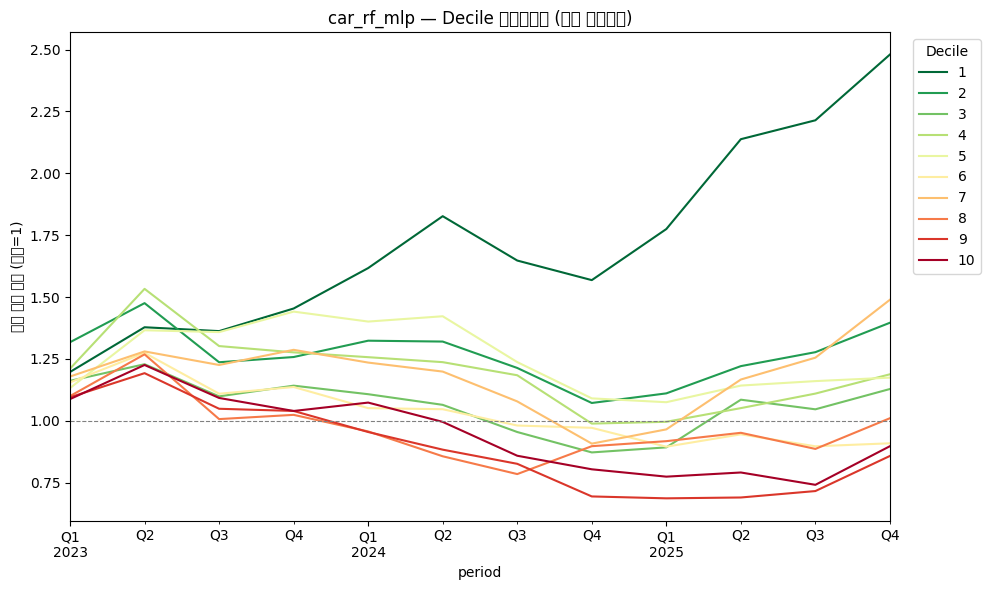


=== car_lasso_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           1.3756       0.0801      0.1118         12
2           0.6035       0.0463      0.1203         12
3          -0.0410       0.0004      0.0924         12
4           0.0027       0.0058      0.1120         12
5           0.4267       0.0363      0.1233         12
6          -0.0667      -0.0008      0.1029         12
7           0.0427       0.0102      0.1225         12
8           0.6115       0.0475      0.1269         12
9          -0.2978      -0.0227      0.1150         12
10         -0.0826      -0.0028      0.1009         12

--- car_lasso_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-9            -0.4744 -0.4744  0.4013      2
-8            -0.2546 -0.2546     NaN      1
-7             0.0000  0.0000     NaN      1
-6            -0.0806 -0.1183  0.06

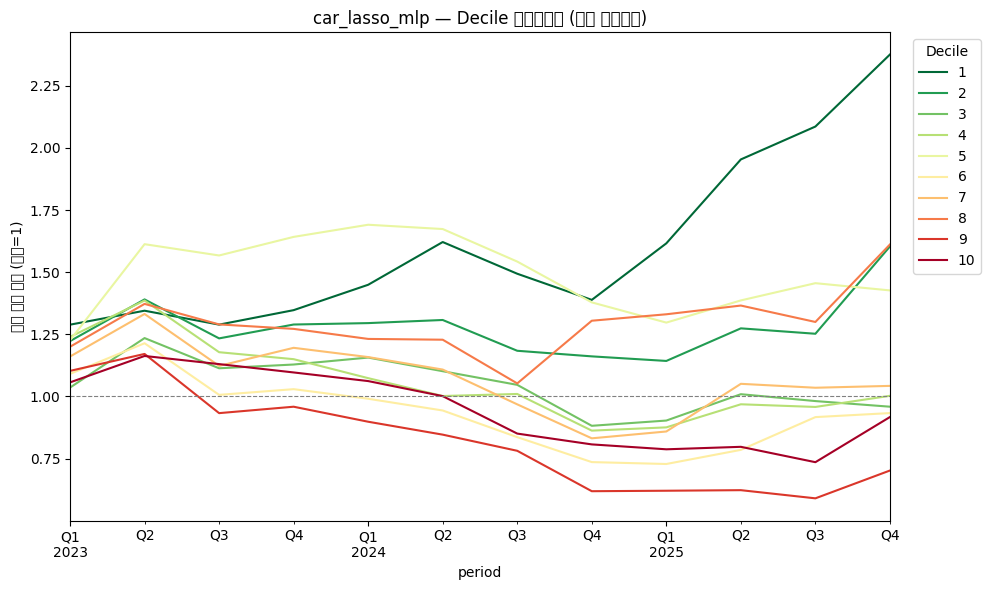


=== car_xgboost Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           0.8140       0.0564      0.1112         12
2           0.4437       0.0350      0.0973         12
3           0.3887       0.0360      0.1385         12
4           0.4174       0.0400      0.1570         12
5           0.2175       0.0218      0.1058         12
6           0.3856       0.0335      0.1160         12
7           0.3539       0.0308      0.1079         12
8          -0.2238      -0.0149      0.1156         12
9          -0.0803      -0.0056      0.0526         12
10         -0.3366      -0.0275      0.1169         12

--- car_xgboost Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-7            -0.0700 -0.1056  0.0894      4
-6             0.0083  0.0596  0.1389      6
-5             0.0074  0.0175  0.1071     14
-4             0.0081 -0.0250  0.2041  

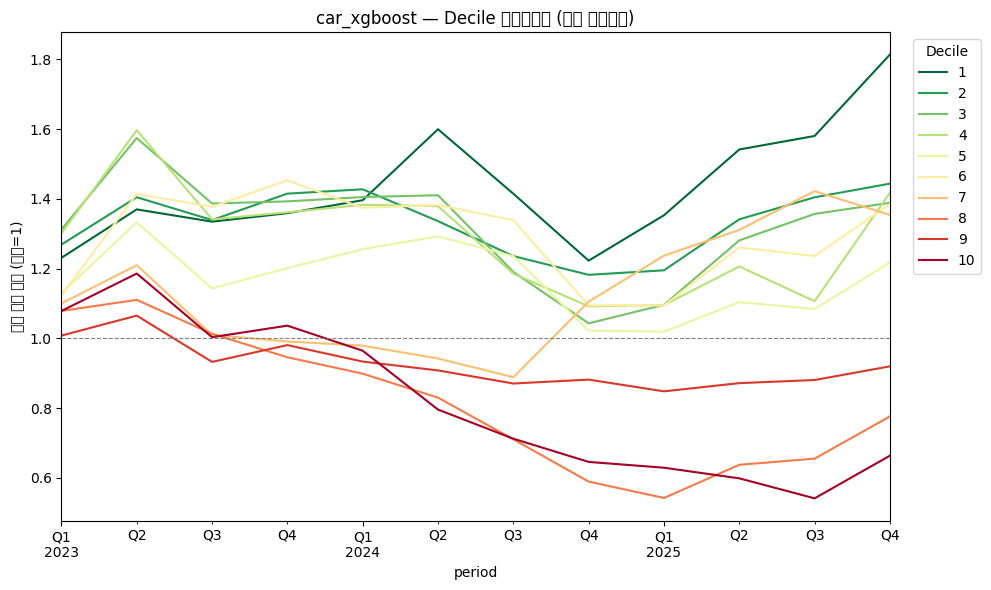


=== semi_rf_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           1.7418       0.0987      0.1558         12
2           2.1882       0.1207      0.2044         12
3           1.0391       0.0824      0.2302         12
4           1.0616       0.0785      0.1904         12
5           1.0231       0.0764      0.1902         12
6           0.6476       0.0591      0.1938         12
7           0.6135       0.0533      0.1649         12
8           0.9574       0.0670      0.1471         12
9           0.3708       0.0405      0.1822         12
10          0.2884       0.0422      0.2234         12

--- semi_rf_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-7             0.0210  0.0210     NaN      1
-6             0.0924  0.0924     NaN      1
-5            -0.0686 -0.0802  0.2309      5
-4             0.2161  0.0165  0.4186  

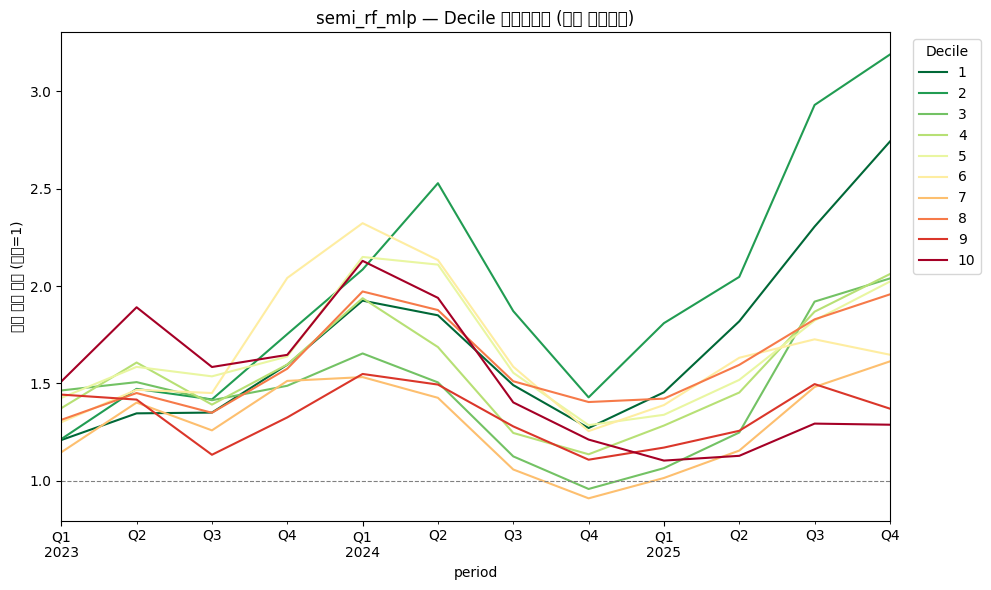


=== semi_lasso_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           1.2355       0.0774      0.1363         12
2           0.9630       0.0718      0.1747         12
3           1.2088       0.0823      0.1764         12
4           2.0810       0.1183      0.2179         12
5           1.3478       0.0901      0.1938         12
6           0.7403       0.0624      0.1813         12
7           2.0003       0.1136      0.1996         12
8          -0.0103       0.0131      0.1768         12
9           0.2759       0.0359      0.1882         12
10          0.4147       0.0513      0.2290         12

--- semi_lasso_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-9            -0.0230 -0.0230  0.0310      2
-8             0.2421  0.1694  0.2678      3
-7             0.2093  0.2110  0.1026      5
-6            -0.0194 -0.0090  0.

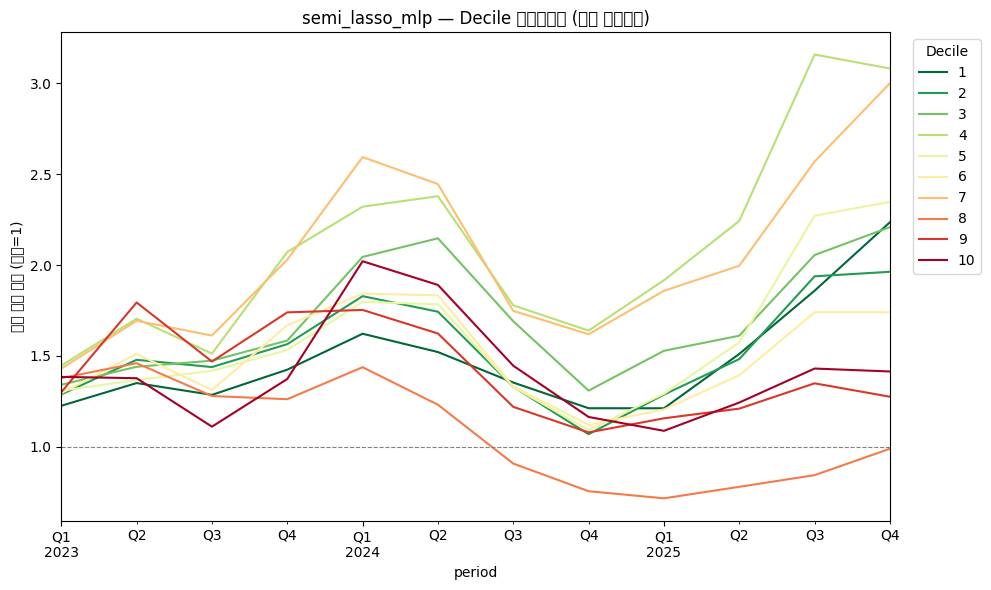


=== semi_xgboost Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           1.2333       0.0804      0.1570         12
2           1.7480       0.1078      0.2138         12
3           2.5456       0.1368      0.2466         12
4           2.2878       0.1174      0.1715         12
5           0.9931       0.0745      0.1901         12
6           0.1902       0.0279      0.1649         12
7           0.3395       0.0352      0.1528         12
8           0.3020       0.0410      0.2035         12
9           0.5970       0.0482      0.1374         12
10          0.3168       0.0448      0.2309         12

--- semi_xgboost Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-6            -0.0429 -0.0429  0.0753      2
-5             0.1291  0.1019  0.1207      8
-4             0.0995  0.0000  0.3571     17
-3             0.1014  0.0784  0.2769

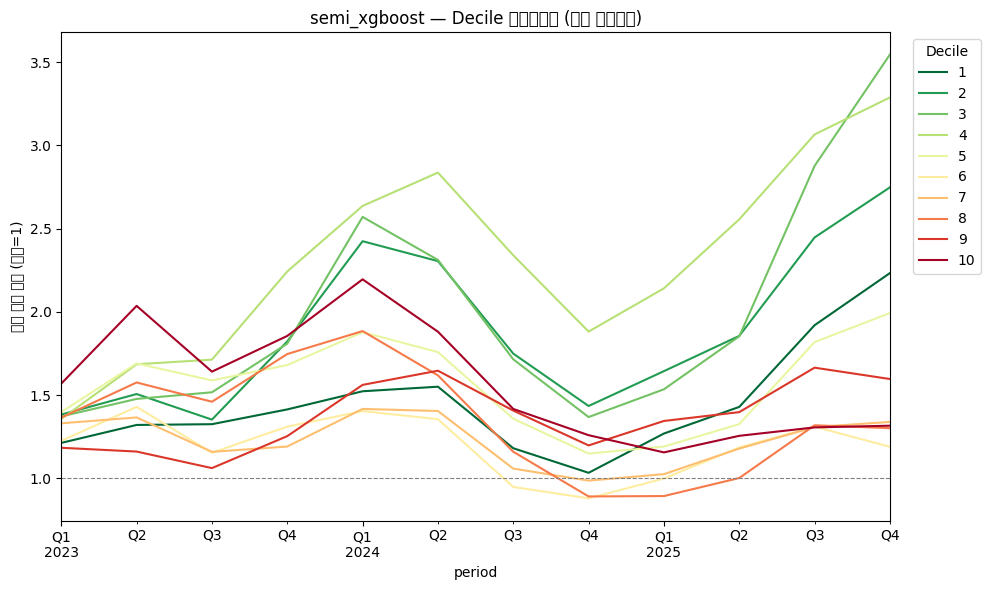


=== ship_rf_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           0.4964       0.0429      0.1505         12
2           2.2686       0.1225      0.2321         12
3           2.4290       0.1383      0.2839         12
4           1.8712       0.1310      0.3264         12
5           0.2320       0.0378      0.2257         12
6          10.8995       0.3259      0.6958         12
7          -0.0989       0.0032      0.1661         12
8           1.4879       0.0984      0.2164         12
9           0.4461       0.0447      0.1751         12
10          1.4906       0.1094      0.2784         12

--- ship_rf_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-7            -0.1385 -0.1385     NaN      1
-6            -0.1779 -0.1779  0.1660      2
-4             0.0151  0.0151  0.1287      2
-3            -0.1106  0.0644  0.3610  

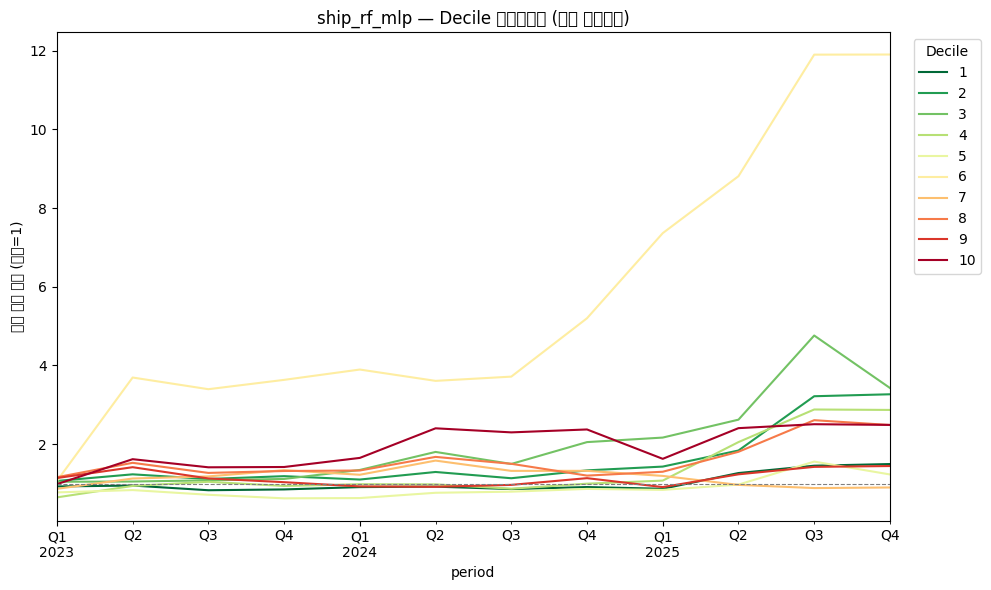


=== ship_lasso_mlp Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           0.8096       0.0608      0.1577         12
2           0.1864       0.0381      0.2480         12
3           1.5606       0.0919      0.1526         12
4           1.7787       0.1190      0.2939         12
5           0.3103       0.0372      0.1899         12
6           0.8822       0.0726      0.2039         12
7           1.2412       0.0806      0.1595         12
8           2.8923       0.1438      0.2481         12
9           1.8229       0.1001      0.1592         12
10          3.1131       0.2177      0.6368         12

--- ship_lasso_mlp Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-8            -0.2311 -0.2311     NaN      1
-7             0.0000  0.0000     NaN      1
-6             0.3131  0.3131     NaN      1
-5            -0.0183 -0.0391  0.

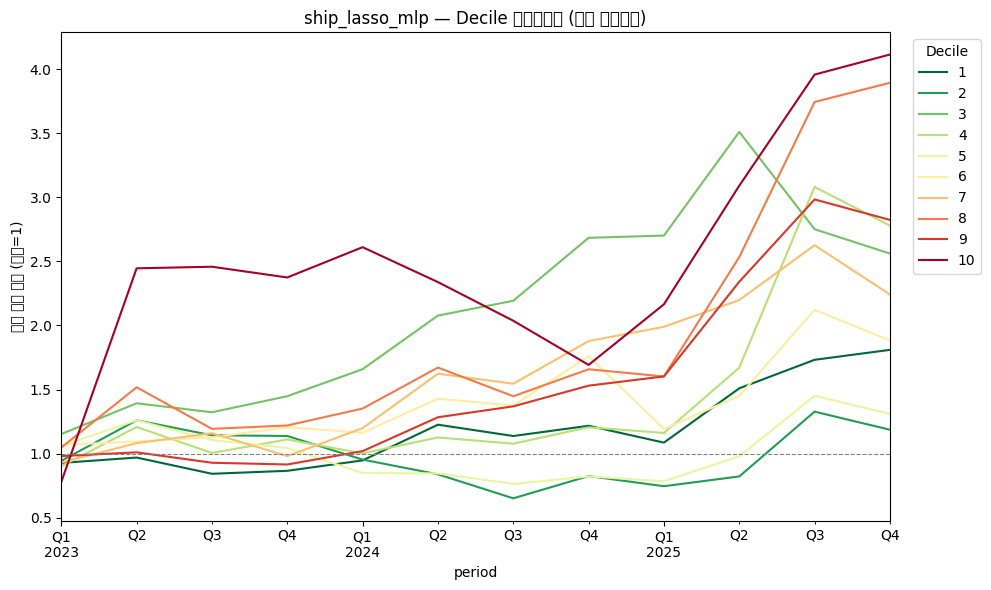


=== ship_xgboost Decile 포트폴리오 ===
        cum_return  mean_return  volatility  n_periods
Decile                                                
1           2.3893       0.1216      0.1964         12
2           0.8638       0.0731      0.2220         12
3           3.8590       0.1592      0.2297         12
4           3.7441       0.1654      0.2708         12
5           3.0841       0.1479      0.2532         12
6           2.0922       0.1114      0.1816         12
7           5.0295       0.1905      0.2974         12
8          -0.4628      -0.0390      0.1490         12
9          -0.6867      -0.0817      0.1463         12
10          0.7167       0.1185      0.5446         12

--- ship_xgboost Decile 전이별 평균 Return ---
                 mean  median     std  count
decile_change                               
-7             0.0631  0.0631     NaN      1
-6             0.5486  0.5486     NaN      1
-5             0.4583  0.4583     NaN      1
-3             0.0681  0.0498  0.3307

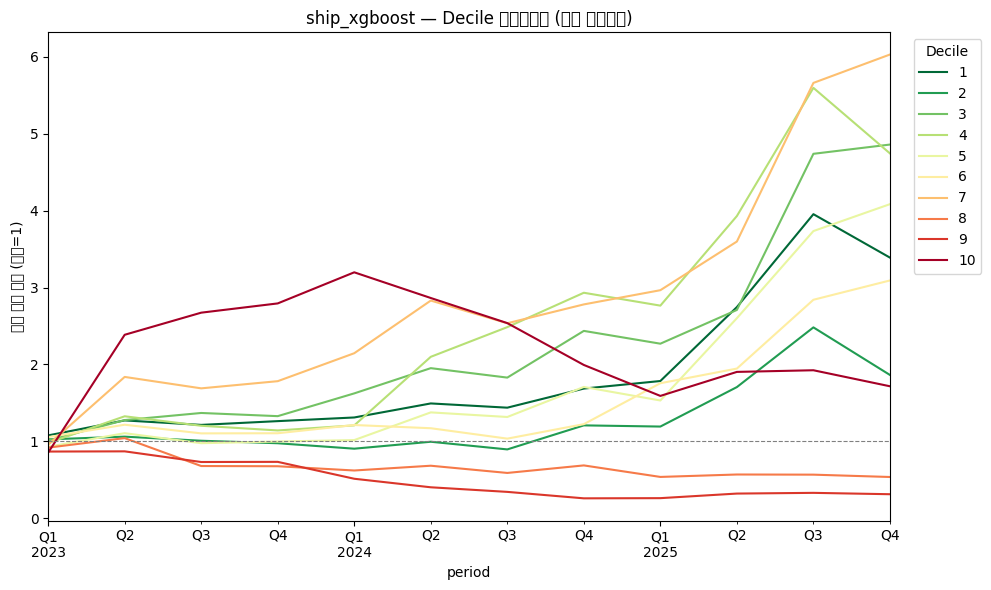


========== Long-Short (D1 - D10) 통계 + BH 보정 ==========
                mean_LS (D1-D10)  t_stat   p_raw  sharpe_ann  ci_low  ci_high  \
key                                                                             
car_rf_mlp                0.0870  3.6809  0.0036      2.1252  0.0411   0.1285   
car_lasso_mlp             0.0828  2.5880  0.0252      1.4942  0.0204   0.1416   
car_xgboost               0.0839  2.5455  0.0272      1.4696  0.0235   0.1498   
semi_rf_mlp               0.0566  1.1973  0.2564      0.6913 -0.0385   0.1400   
semi_lasso_mlp            0.0261  0.5787  0.5744      0.3341 -0.0629   0.1023   
semi_xgboost              0.0356  0.6096  0.5545      0.3520 -0.0766   0.1382   
ship_rf_mlp              -0.0665 -0.9687  0.3535     -0.5593 -0.2039   0.0515   
ship_lasso_mlp           -0.1569 -0.8479  0.4145     -0.4896 -0.5468   0.1060   
ship_xgboost              0.0032  0.0202  0.9843      0.0116 -0.3379   0.2303   

                n_periods    p_BH  sig_BH_5%  
key  

In [260]:
def decile_portfolio_stats(df):
    port = (
        df.groupby(['period', 'Decile'])['Return']
        .mean()
        .unstack('Decile')
        .sort_index()
    )
    summary = pd.DataFrame({
        'cum_return': (1 + port).prod() - 1,
        'mean_return': port.mean(),
        'volatility': port.std(),
        'n_periods': port.count(),
    })
    summary.index.name = 'Decile'
    return summary, port


def decile_membership(df):
    return {
        period: {int(decile): sub['corp_code'].tolist()
                 for decile, sub in g.groupby('Decile')}
        for period, g in df.groupby('period')
    }


def plot_decile_cumulative(port_ts, title):
    import matplotlib.pyplot as plt
    cum = (1 + port_ts).cumprod()
    ax = cum.plot(figsize=(10, 6), colormap='RdYlGn_r')
    ax.set_title(f"{title} — Decile 누적수익률 (분기 리밸런싱)")
    ax.set_xlabel('period')
    ax.set_ylabel('누적 성장 배수 (시작=1)')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
    ax.legend(title='Decile', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return ax


def long_short_stats(port_ts, low=1, high=10, n_boot=2000, seed=42, periods_per_year=4):
    """D{low} - D{high} long-short 포트폴리오의 시계열 통계.

    부호: 양수면 저위험(D1) 우세, 음수면 고위험(D10) 우세.
    """
    from scipy import stats as sps
    ls = (port_ts[low] - port_ts[high]).dropna()
    n = len(ls)
    mean = ls.mean()
    std = ls.std(ddof=1)
    if n < 2 or std == 0 or np.isnan(std):
        return {'mean': mean, 'std': std, 't_stat': np.nan, 'p_value': np.nan,
                'sharpe_q': np.nan, 'sharpe_ann': np.nan,
                'ci_low': np.nan, 'ci_high': np.nan, 'n': n}

    t_stat, p_value = sps.ttest_1samp(ls.values, popmean=0.0)
    sharpe_q = mean / std
    sharpe_ann = sharpe_q * np.sqrt(periods_per_year)

    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = ls.values[idx].mean(axis=1)
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    return {'mean': mean, 'std': std, 't_stat': t_stat, 'p_value': p_value,
            'sharpe_q': sharpe_q, 'sharpe_ann': sharpe_ann,
            'ci_low': ci_low, 'ci_high': ci_high, 'n': n}


def bh_adjust(p_values):
    """Benjamini-Hochberg FDR adjusted p-values. NaN은 그대로 통과."""
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan)
    valid = ~np.isnan(p)
    pv = p[valid]
    m = len(pv)
    if m == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    unadj = np.empty(m)
    unadj[order] = adj
    out[valid] = unadj
    return out


def decile_transition_returns(df):
    d = df.sort_values(['corp_code', 'period']).copy()
    d['prev_Decile'] = d.groupby('corp_code')['Decile'].shift(1)
    d['next_Return'] = d.groupby('corp_code')['Return'].shift(-1)
    d = d.dropna(subset=['prev_Decile', 'next_Return'])
    d['decile_change'] = (d['Decile'] - d['prev_Decile']).astype(int)

    by_change = d.groupby('decile_change')['next_Return'].agg(['mean', 'median', 'std', 'count'])
    matrix = d.pivot_table(
        index='prev_Decile', columns='Decile', values='next_Return', aggfunc='mean'
    )
    return by_change, matrix


results = {}
sectors = ['car', 'semi', 'ship']
methods = ['rf_mlp', 'lasso_mlp', 'xgboost']
for sector in sectors:
    for method in methods:
        dict_key = f"{sector}_{method}"

        # 딕셔너리에 해당 키가 없으면 건너뜀
        if dict_key not in final_ff_dfs:
            print(f"⚠️ {dict_key} 데이터가 없어 건너뜁니다.")
            continue

        model_df = final_ff_dfs[dict_key].copy()

        # 1. 결측치 제거
        cols = ['period', 'Return', 'Mkt_RF', 'SMB', 'HML', 'Earning_Factor']
        model_df = model_df.dropna(subset=cols)

        # ==========================================
        # 2. 분기별 어닝 팩터 기준 10분위수(Decile) 할당
        # ==========================================
        # rank(method='first')를 사용하여 확률값이 겹쳐도 강제로 10등분하도록 처리
        # 1분위(D1): 가장 낮음(저위험) ~ 10분위(D10): 가장 높음(고위험)
        model_df['Decile'] = model_df.groupby('period')['Earning_Factor'].transform(
            lambda x: pd.qcut(x.rank(method='first'), q=10, labels=False) + 1
        )

        # ==========================================
        # 3. Decile 포트폴리오 수익률 / 변동성
        # ==========================================
        stats, port_ts = decile_portfolio_stats(model_df)
        by_change, trans_matrix = decile_transition_returns(model_df)
        members = decile_membership(model_df)
        ls = long_short_stats(port_ts, low=1, high=10)

        results[dict_key] = {
            'stats': stats,
            'port_ts': port_ts,
            'by_change': by_change,
            'matrix': trans_matrix,
            'members': members,
            'long_short': ls,
        }

        print(f"\n=== {dict_key} Decile 포트폴리오 ===")
        print(stats.round(4))
        print(f"\n--- {dict_key} Decile 전이별 평균 Return ---")
        print(by_change.round(4))

        plot_decile_cumulative(port_ts, dict_key)


# ==========================================
# 4. 전 셀(sector × method) long-short 유의성 + 다중비교 보정
# ==========================================
ls_rows = []
for key, r in results.items():
    ls = r['long_short']
    ls_rows.append({
        'key': key,
        'mean_LS (D1-D10)': ls['mean'],
        't_stat': ls['t_stat'],
        'p_raw': ls['p_value'],
        'sharpe_ann': ls['sharpe_ann'],
        'ci_low': ls['ci_low'],
        'ci_high': ls['ci_high'],
        'n_periods': ls['n'],
    })

ls_summary = pd.DataFrame(ls_rows).set_index('key')
ls_summary['p_BH'] = bh_adjust(ls_summary['p_raw'].values)
ls_summary['sig_BH_5%'] = ls_summary['p_BH'] < 0.05

print("\n========== Long-Short (D1 - D10) 통계 + BH 보정 ==========")
print(ls_summary.round(4))
results['_ls_summary'] = ls_summary